In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st 


In [42]:
df = pd.read_csv('ecomdata.csv', encoding='latin-1', on_bad_lines='skip')
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [5]:
#to print number of rows and columns in dataset
print(df.shape)

(541909, 8)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
df=df.dropna(subset=['CustomerID'])
df=df.dropna(subset=['Description'])
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [9]:
df=df.drop_duplicates()
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['CustomerID']=df['CustomerID'].astype(int)


In [10]:
df=df[df['Quantity']>0]
df=df[df['UnitPrice']>0]
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [11]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,392692.000000,392692,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,180.492832,NaN,22.241836,1713.539549


In [12]:
Q1=df['Quantity'].quantile(0.25)
Q3=df['Quantity'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-(1.5*IQR)
upper_bound=Q3+(1.5*IQR)
df=df[(df['Quantity']>=lower_bound)&(df['Quantity']<=upper_bound)]


In [13]:
df['TotalPrice']=df['Quantity']*df['UnitPrice']
df.describe()


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,367076.000000,367076,367076.000000,367076.000000,367076.000000
mean,7.094719,2011-07-11 02:45:25.328814592,3.240009,15302.780408,14.510876
min,1.000000,2010-12-01 08:26:00,0.001000,12347.000000,0.001000
25%,2.000000,2011-04-07 11:30:00,1.250000,13975.000000,4.250000
50%,4.000000,2011-07-31 15:00:00,1.950000,15182.000000,10.500000
75%,12.000000,2011-10-20 15:57:00,3.750000,16807.000000,17.700000
max,27.000000,2011-12-09 12:50:00,8142.750000,18287.000000,8142.750000
std,6.670837,NaN,22.972315,1712.040348,28.229733


In [14]:
#extracting time features using invoice date
df['Year']=df['InvoiceDate'].dt.year
df['Month']=df['InvoiceDate'].dt.month
df['Day']=df['InvoiceDate'].dt.day
df['Hour']=df['InvoiceDate'].dt.hour
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8


In [15]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
Year           0
Month          0
Day            0
Hour           0
dtype: int64

In [16]:
print(df.shape)
df.describe()

(367076, 13)


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,Year,Month,Day,Hour
count,367076.000000,367076,367076.000000,367076.000000,367076.000000,367076.000000,367076.000000,367076.000000,367076.000000
mean,7.094719,2011-07-11 02:45:25.328814592,3.240009,15302.780408,14.510876,2010.934697,7.611184,15.047966,12.755909
min,1.000000,2010-12-01 08:26:00,0.001000,12347.000000,0.001000,2010.000000,1.000000,1.000000,6.000000
25%,2.000000,2011-04-07 11:30:00,1.250000,13975.000000,4.250000,2011.000000,5.000000,7.000000,11.000000
50%,4.000000,2011-07-31 15:00:00,1.950000,15182.000000,10.500000,2011.000000,8.000000,15.000000,13.000000
75%,12.000000,2011-10-20 15:57:00,3.750000,16807.000000,17.700000,2011.000000,11.000000,22.000000,14.000000
max,27.000000,2011-12-09 12:50:00,8142.750000,18287.000000,8142.750000,2011.000000,12.000000,31.000000,20.000000
std,6.670837,NaN,22.972315,1712.040348,28.229733,0.247059,3.417657,8.660018,2.265197


In [17]:
#eda on customer id
customer_revenue=df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
customer_revenue.sort_values(by='TotalPrice',ascending=False).head(10)


,CustomerID,TotalPrice
1843,14911,114191.81
1264,14096,61295.62
549,13089,43359.28
3925,17841,38793.08
1260,14088,27597.28
1406,14298,27322.08
1306,14156,26946.71
324,12748,25640.52
1656,14646,25623.12
2131,15311,20602.66


In [18]:
total_revenue=df['TotalPrice'].sum()
print(f'Total Revenue: {total_revenue}')
total_orders=df['CustomerID'].nunique()
print(f'Total Orders: {total_orders}')
average_order_value=total_revenue/total_orders
print(f'Average Order Value: {average_order_value}')



Total Revenue: 5326594.354
Total Orders: 4238
Average Order Value: 1256.8651142048136


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'United Kingdom'),
  Text(1, 0, 'Germany'),
  Text(2, 0, 'France'),
  Text(3, 0, 'EIRE'),
  Text(4, 0, 'Spain'),
  Text(5, 0, 'Switzerland'),
  Text(6, 0, 'Belgium'),
  Text(7, 0, 'Netherlands'),
  Text(8, 0, 'Portugal'),
  Text(9, 0, 'Norway')])

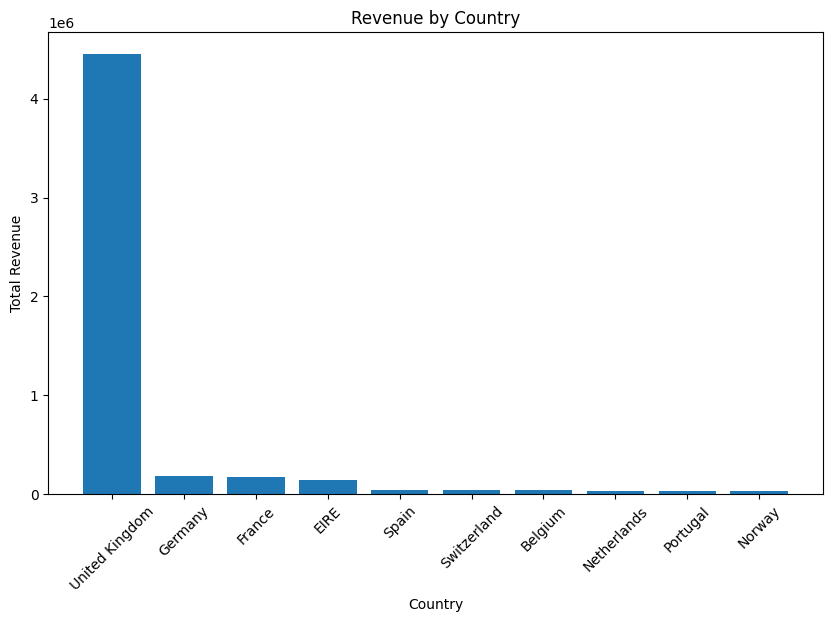

In [19]:
#revenue by country 
country_revenue=df.groupby('Country')['TotalPrice'].sum().reset_index()
#bar graph showing revenue by top 10 countries 
top_countries=country_revenue.sort_values(by='TotalPrice',ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.bar(top_countries['Country'],top_countries['TotalPrice'])
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.title('Revenue by Country')
plt.xticks(rotation=45)

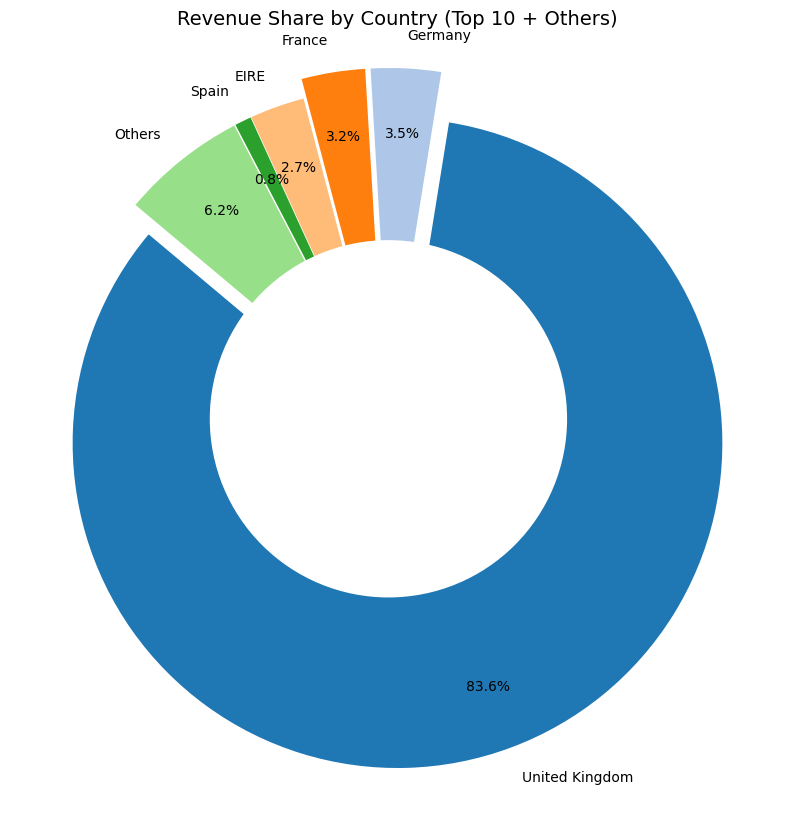

In [20]:
import matplotlib.pyplot as plt

# Top 10 countries
top_countries = country_revenue.sort_values(by='TotalPrice', ascending=False).head(5)

# Remaining countries
other_countries = country_revenue[~country_revenue['Country'].isin(top_countries['Country'])]
other_revenue = other_countries['TotalPrice'].sum()

# Labels and sizes
labels = top_countries['Country'].tolist() + ['Others']
sizes = top_countries['TotalPrice'].tolist() + [other_revenue]

# Better colors (use a colormap)
colors = plt.cm.tab20.colors  # nice distinct colors

# Explode only top 3 for emphasis
explode = [0.08 if i < 3 else 0.02 for i in range(len(labels))]

# Plot
plt.figure(figsize=(10,10))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    pctdistance=0.8,
    textprops={'fontsize': 10}
)

# Draw circle for donut style (more modern)
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Revenue Share by Country (Top 10 + Others)', fontsize=14)
plt.axis('equal')

plt.show()

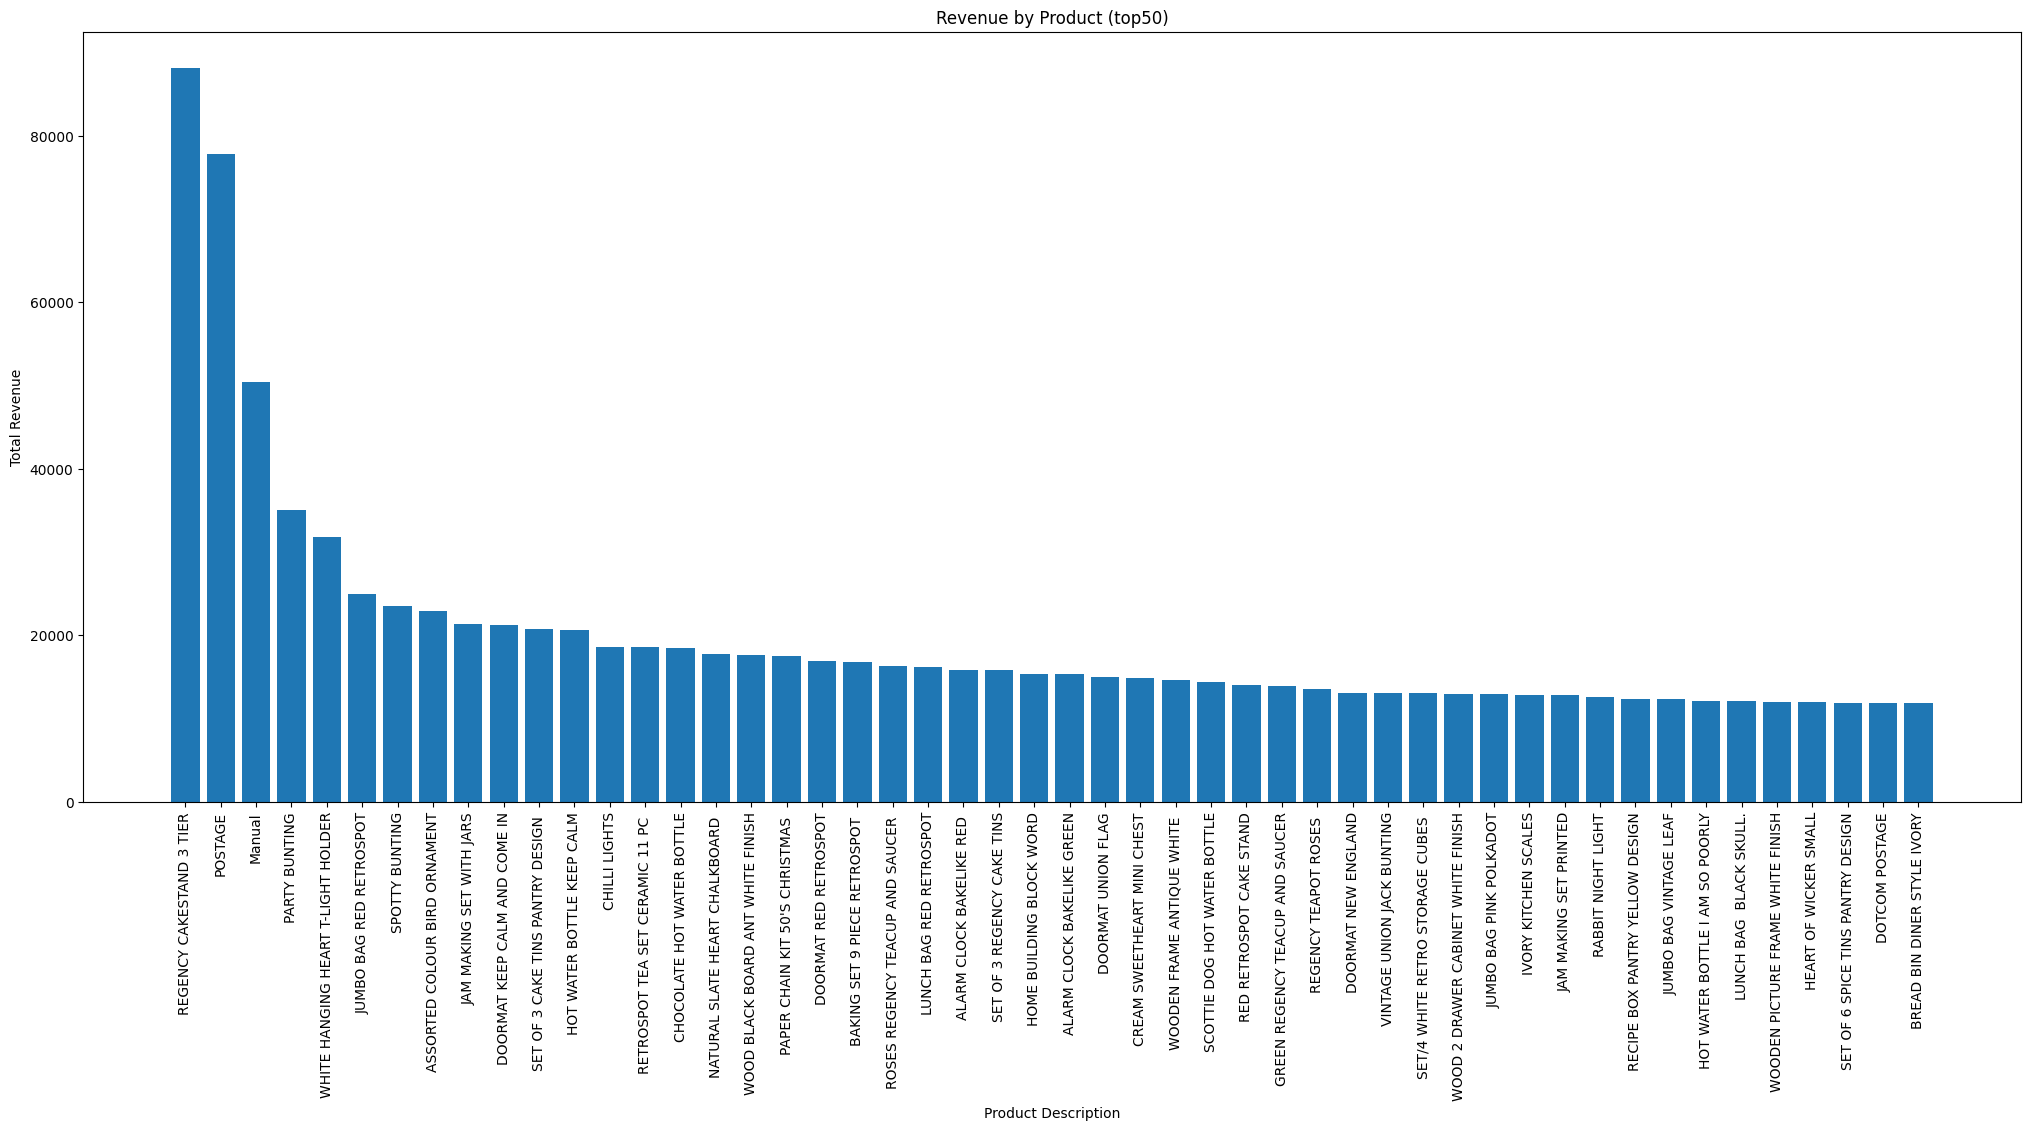

In [21]:
product_revenue=df.groupby('Description')['TotalPrice'].sum().reset_index()
#to plot top 25 products and their revenue and rest as others in bar graph
top_products=product_revenue.sort_values(by='TotalPrice',ascending=False).head(50)
#other_products=product_revenue[~product_revenue['Description'].isin(top_products['Description'])]
#other_revenue=other_products['TotalPrice'].sum()
#top_products = pd.concat([top_products, pd.DataFrame({'Description': ['Others'], 'TotalPrice': [other_revenue]})], ignore_index=True)
plt.figure(figsize=(25,10))
plt.bar(top_products['Description'],top_products['TotalPrice'])
plt.xlabel('Product Description')
plt.ylabel('Total Revenue')
plt.title('Revenue by Product (top50)')
plt.xticks(rotation=90)
plt.show()


<Axes: ylabel='Frequency'>

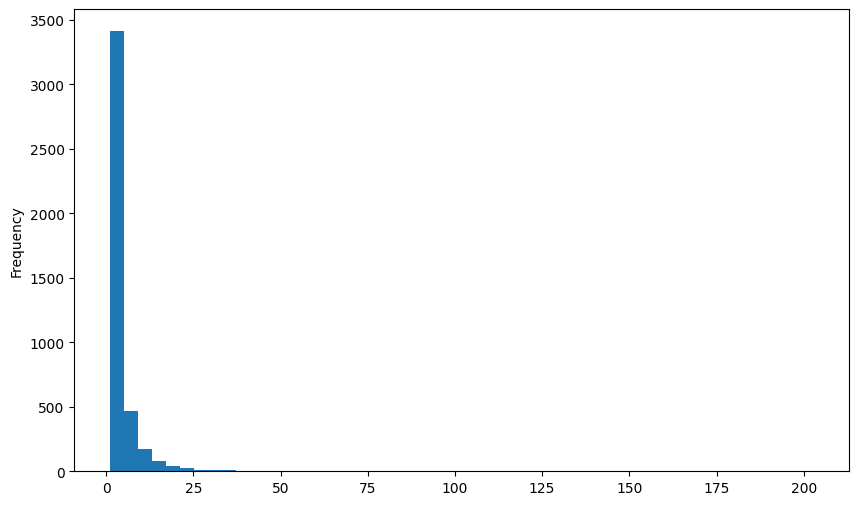

In [22]:
#customer purchase behavior analysis
customer_purchase_behavior=df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
customer_purchase_behavior.sort_values(by='TotalPrice',ascending=False).head(25)
orders_per_customer=df.groupby('CustomerID')['InvoiceNo'].nunique()
orders_per_customer.plot(kind='hist',bins=50,figsize=(10,6))


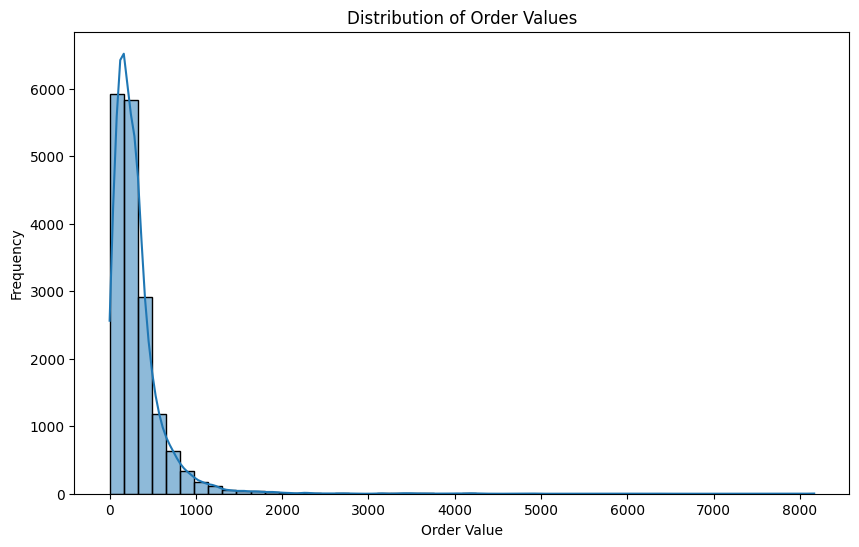

In [23]:
#order value distribution 
order_value_distribution=df.groupby('InvoiceNo')['TotalPrice'].sum().reset_index()
plt.figure(figsize=(10,6))
sns.histplot(order_value_distribution['TotalPrice'], bins=50, kde=True)
plt.xlabel('Order Value')
plt.ylabel('Frequency')
plt.title('Distribution of Order Values')
plt.show()


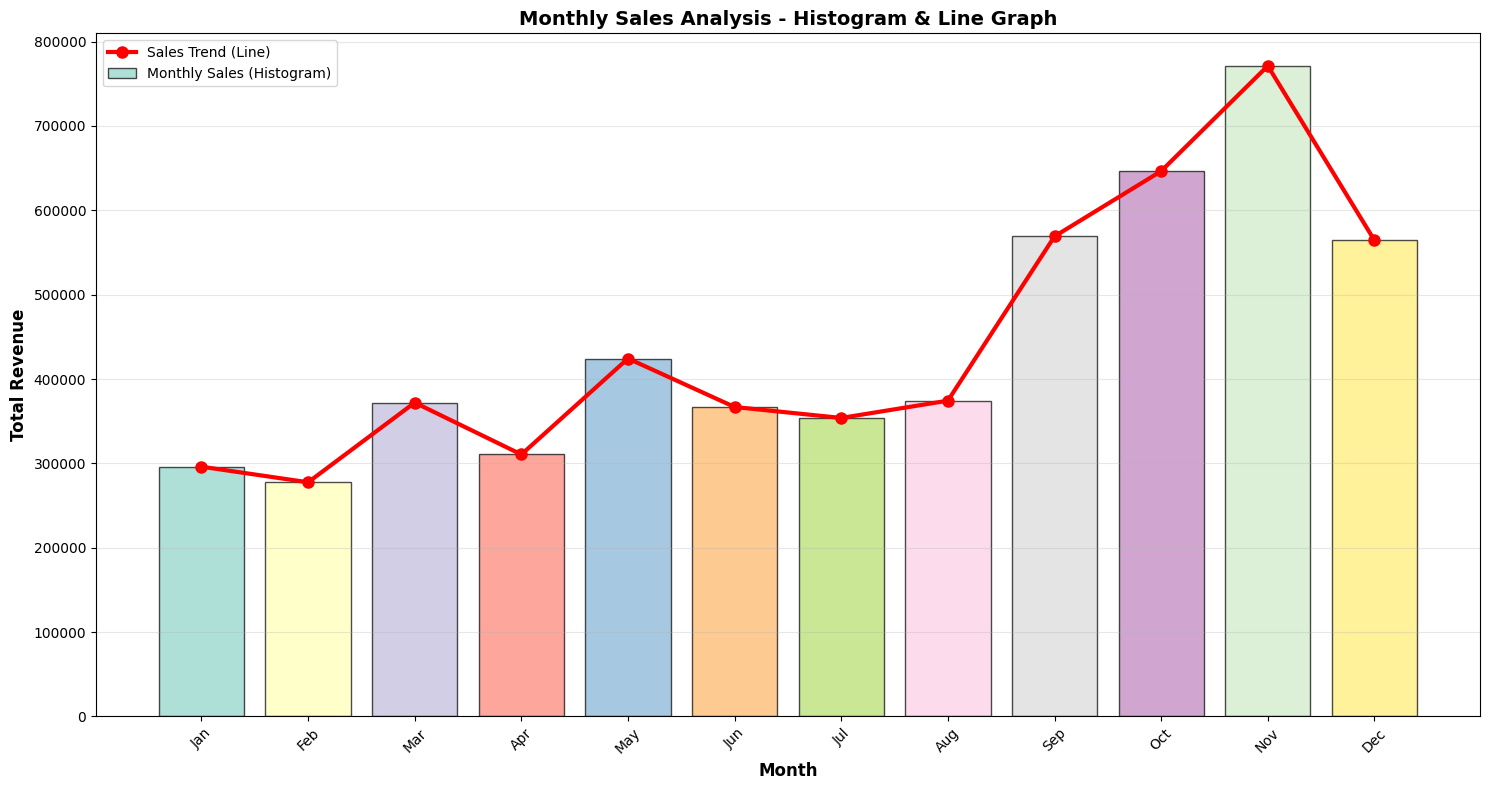

In [24]:
import calendar
sales_by_month = df.groupby('Month')['TotalPrice'].sum().reset_index()
month_names = [calendar.month_abbr[i] for i in sales_by_month['Month']]
plt.figure(figsize=(15, 8))
colors = plt.cm.Set3(range(len(sales_by_month))) 
plt.bar(month_names, sales_by_month['TotalPrice'], color=colors, alpha=0.7, label='Monthly Sales (Histogram)', edgecolor='black')
plt.plot(month_names, sales_by_month['TotalPrice'], color='red', linewidth=3, marker='o', markersize=8, label='Sales Trend (Line)', linestyle='-')
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Total Revenue', fontsize=12, fontweight='bold')
plt.title('Monthly Sales Analysis - Histogram & Line Graph', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<Axes: >

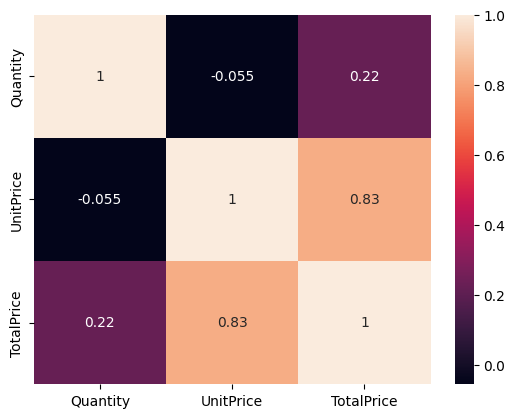

In [25]:
import seaborn as sns

sns.heatmap(df[['Quantity','UnitPrice','TotalPrice']].corr(), annot=True)

SUMMARY STATISTICS
Mean items per order: 150.43
Median items per order: 110
Std deviation: 156.88
Min items: 1
Max items: 2561
Total orders: 17,312


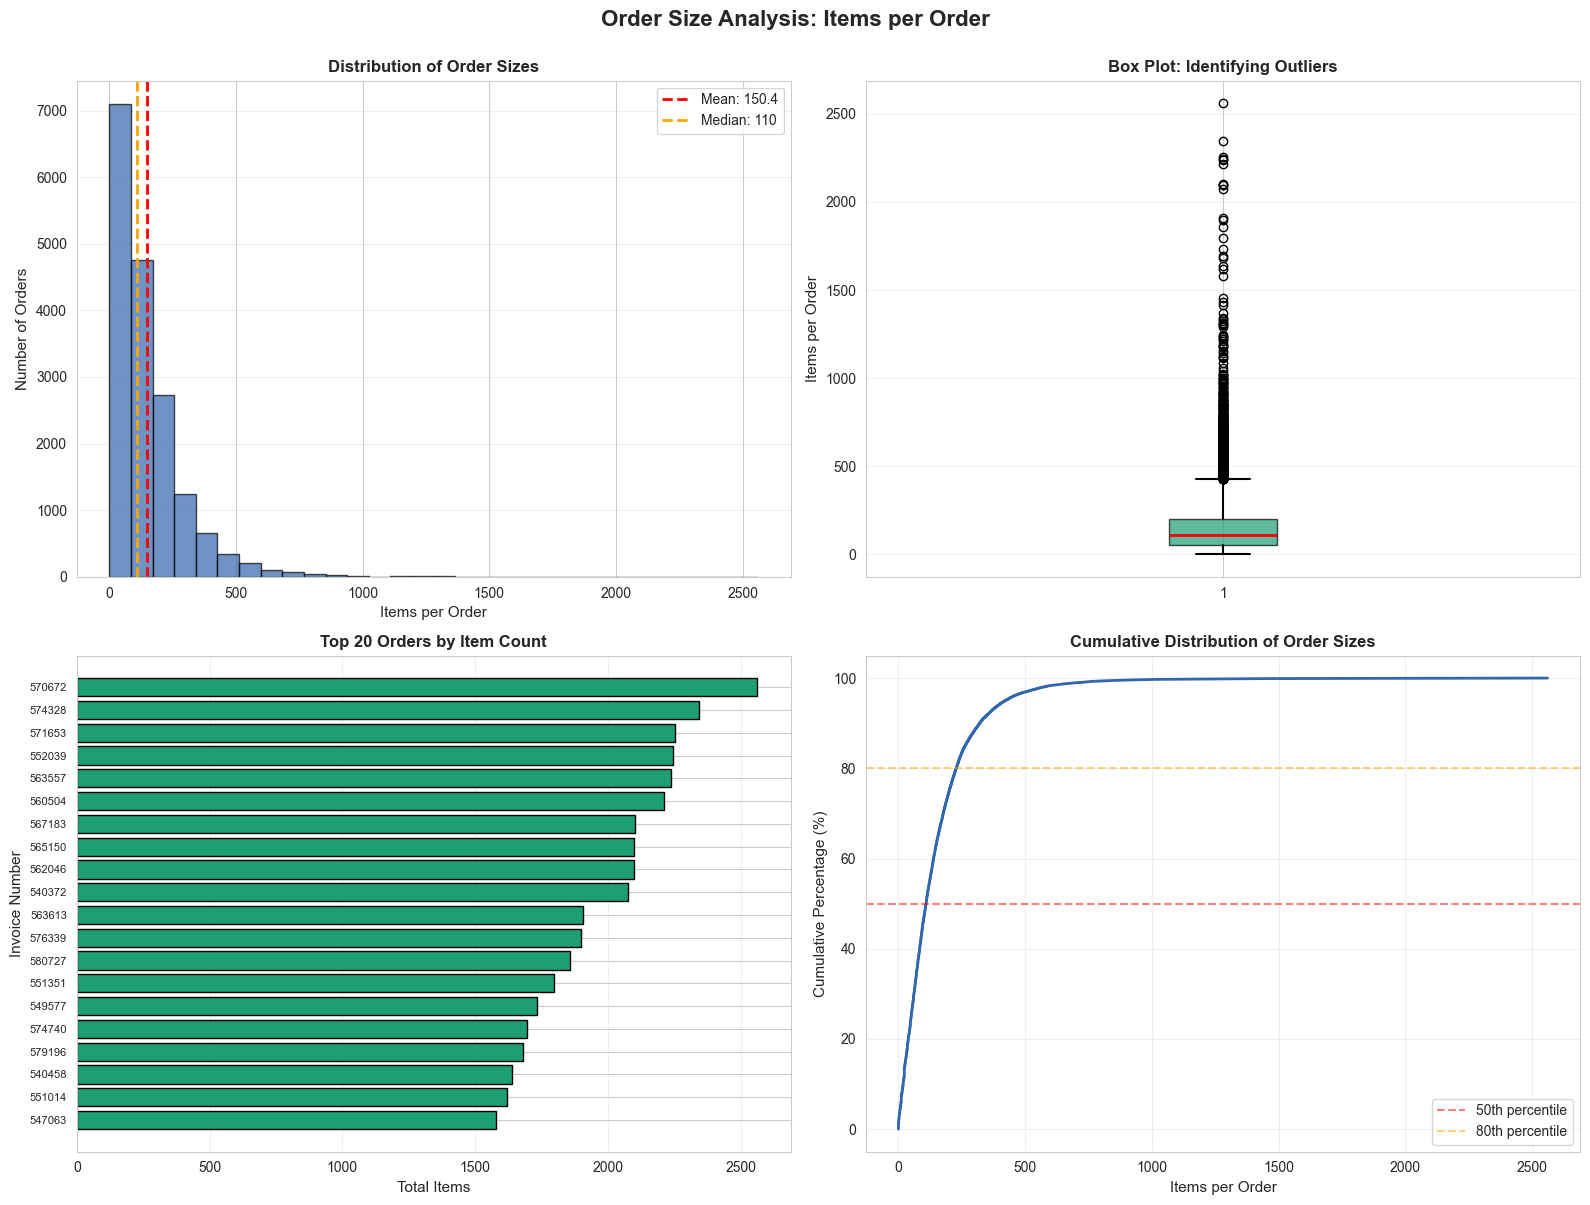


PERCENTILE BREAKDOWN
25th percentile: 51.0 items
50th percentile: 110.0 items
75th percentile: 201.0 items
90th percentile: 321.0 items
95th percentile: 423.0 items
99th percentile: 709.9 items

ORDER SIZE CATEGORIES
OrderSize
Extra Large (50+)    13017
Large (26-50)         1882
Medium (11-25)        1400
Small (1-10)          1013
Name: count, dtype: int64


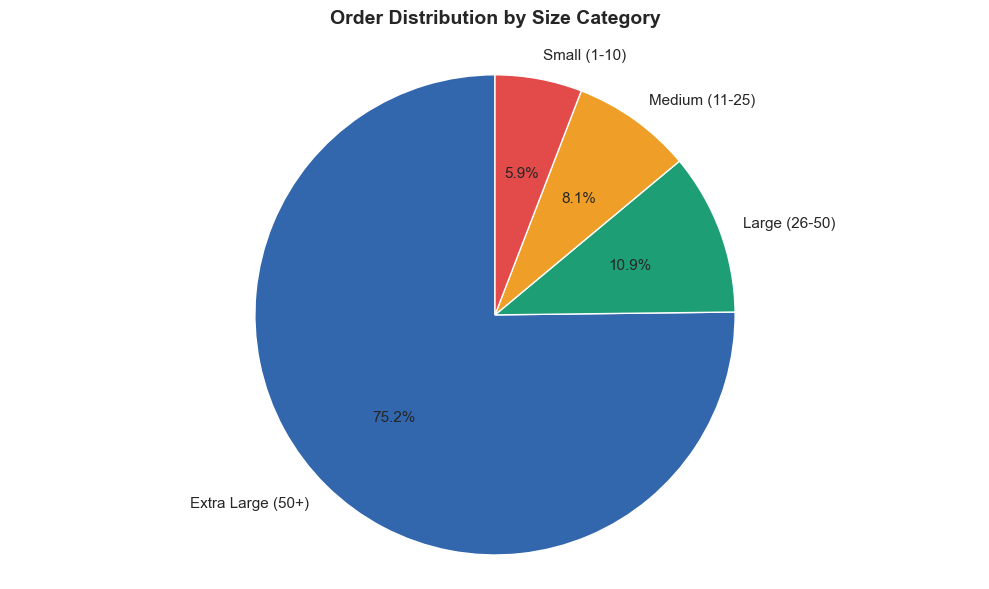


✓ Analysis saved to 'items_per_order_analysis.csv'


In [26]:
#basket size analysis 
items_per_order = df.groupby('InvoiceNo')['Quantity'].sum()
items_per_order_df = (
    df.groupby('InvoiceNo', as_index=False)['Quantity']
    .sum()
    .rename(columns={'Quantity': 'TotalItems'})
    .sort_values('TotalItems', ascending=False)
)
print("=" * 50)
print("SUMMARY STATISTICS")
print("=" * 50)
print(f"Mean items per order: {items_per_order_df['TotalItems'].mean():.2f}")
print(f"Median items per order: {items_per_order_df['TotalItems'].median():.0f}")
print(f"Std deviation: {items_per_order_df['TotalItems'].std():.2f}")
print(f"Min items: {items_per_order_df['TotalItems'].min():.0f}")
print(f"Max items: {items_per_order_df['TotalItems'].max():.0f}")
print(f"Total orders: {len(items_per_order_df):,}")
print("=" * 50)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Order Size Analysis: Items per Order', fontsize=16, fontweight='bold', y=1.00)
axes[0, 0].hist(items_per_order_df['TotalItems'], bins=30, color='#3266ad', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Items per Order', fontsize=11)
axes[0, 0].set_ylabel('Number of Orders', fontsize=11)
axes[0, 0].set_title('Distribution of Order Sizes', fontsize=12, fontweight='bold')
axes[0, 0].axvline(items_per_order_df['TotalItems'].mean(), color='red', linestyle='--', 
                    linewidth=2, label=f'Mean: {items_per_order_df["TotalItems"].mean():.1f}')
axes[0, 0].axvline(items_per_order_df['TotalItems'].median(), color='orange', linestyle='--', 
                    linewidth=2, label=f'Median: {items_per_order_df["TotalItems"].median():.0f}')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 1].boxplot(items_per_order_df['TotalItems'], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#1D9E75', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
axes[0, 1].set_ylabel('Items per Order', fontsize=11)
axes[0, 1].set_title('Box Plot: Identifying Outliers', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
top_20 = items_per_order_df.head(20)
axes[1, 0].barh(range(len(top_20)), top_20['TotalItems'], color='#1D9E75', edgecolor='black')
axes[1, 0].set_yticks(range(len(top_20)))
axes[1, 0].set_yticklabels(top_20['InvoiceNo'], fontsize=8)
axes[1, 0].set_xlabel('Total Items', fontsize=11)
axes[1, 0].set_ylabel('Invoice Number', fontsize=11)
axes[1, 0].set_title('Top 20 Orders by Item Count', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)
sorted_items = items_per_order_df['TotalItems'].sort_values().reset_index(drop=True)
cumulative_pct = (sorted_items.index + 1) / len(sorted_items) * 100
axes[1, 1].plot(sorted_items.values, cumulative_pct, color='#3266ad', linewidth=2)
axes[1, 1].set_xlabel('Items per Order', fontsize=11)
axes[1, 1].set_ylabel('Cumulative Percentage (%)', fontsize=11)
axes[1, 1].set_title('Cumulative Distribution of Order Sizes', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(50, color='red', linestyle='--', alpha=0.5, label='50th percentile')
axes[1, 1].axhline(80, color='orange', linestyle='--', alpha=0.5, label='80th percentile')
axes[1, 1].legend()
plt.tight_layout()
plt.show()
print("\nPERCENTILE BREAKDOWN")
print("=" * 50)
percentiles = [25, 50, 75, 90, 95, 99]
for p in percentiles:
    value = items_per_order_df['TotalItems'].quantile(p/100)
    print(f"{p}th percentile: {value:.1f} items")
print("=" * 50)
# Create categories
def categorize_order(items):
    if items <= 10:
        return 'Small (1-10)'
    elif items <= 25:
        return 'Medium (11-25)'
    elif items <= 50:
        return 'Large (26-50)'
    else:
        return 'Extra Large (50+)'
items_per_order_df['OrderSize'] = items_per_order_df['TotalItems'].apply(categorize_order)
category_counts = items_per_order_df['OrderSize'].value_counts()

print("\nORDER SIZE CATEGORIES")
print("=" * 50)
print(category_counts)
print("=" * 50)
plt.figure(figsize=(10, 6))
colors = ['#3266ad', '#1D9E75', '#EF9F27', '#E24B4A']
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 11})
plt.title('Order Distribution by Size Category', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()
items_per_order_df.to_csv('items_per_order_analysis.csv', index=False)
print("\n✓ Analysis saved to 'items_per_order_analysis.csv'")

                     Recency Frequency Monetary                  
                        mean      mean     mean         sum count
Segment                                                          
At Risk Customers     229.29      1.05   188.29   146301.25   777
High Value Customers   25.81      7.94  2600.57  4262333.11  1639
Loyal Customers        68.26      2.45   669.52   554359.96   828
Potential Loyalists   116.02      1.46   365.79   363600.03   994


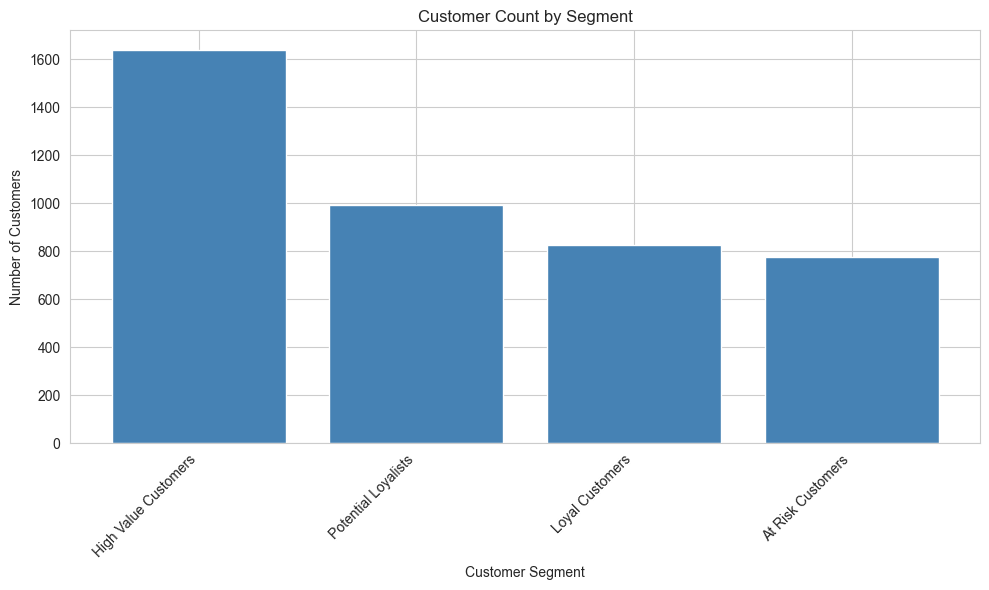

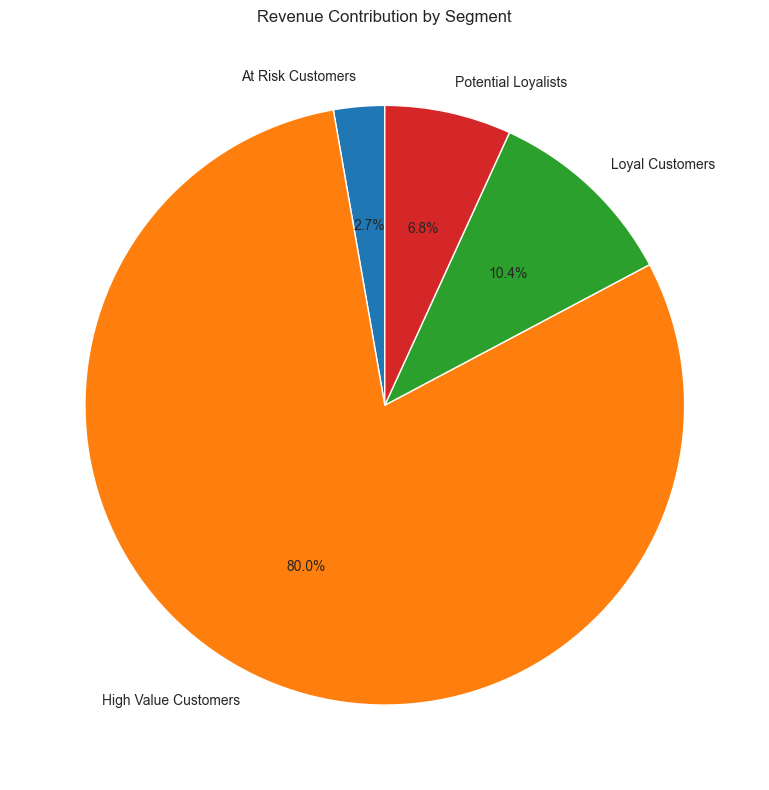

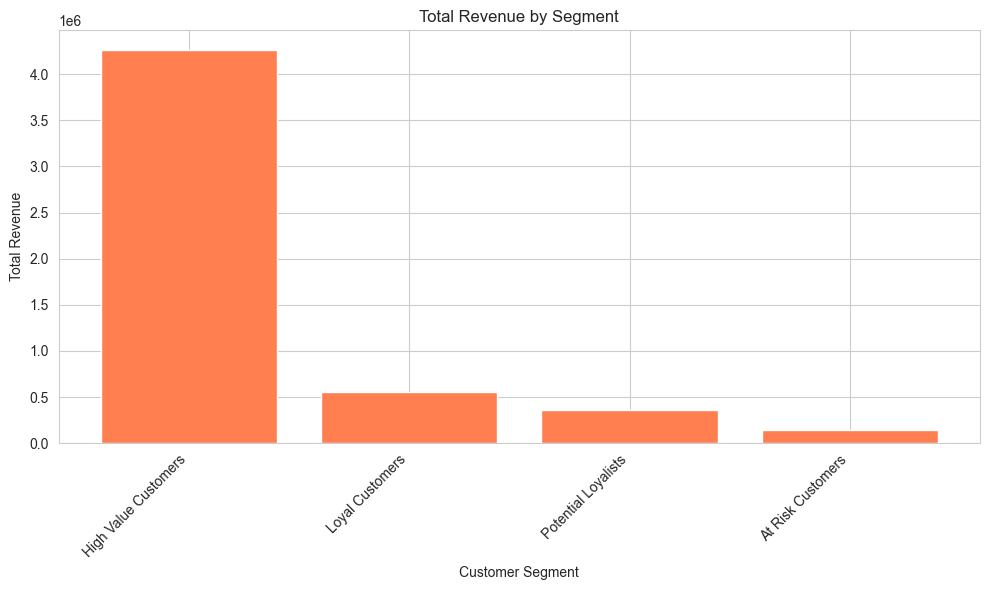

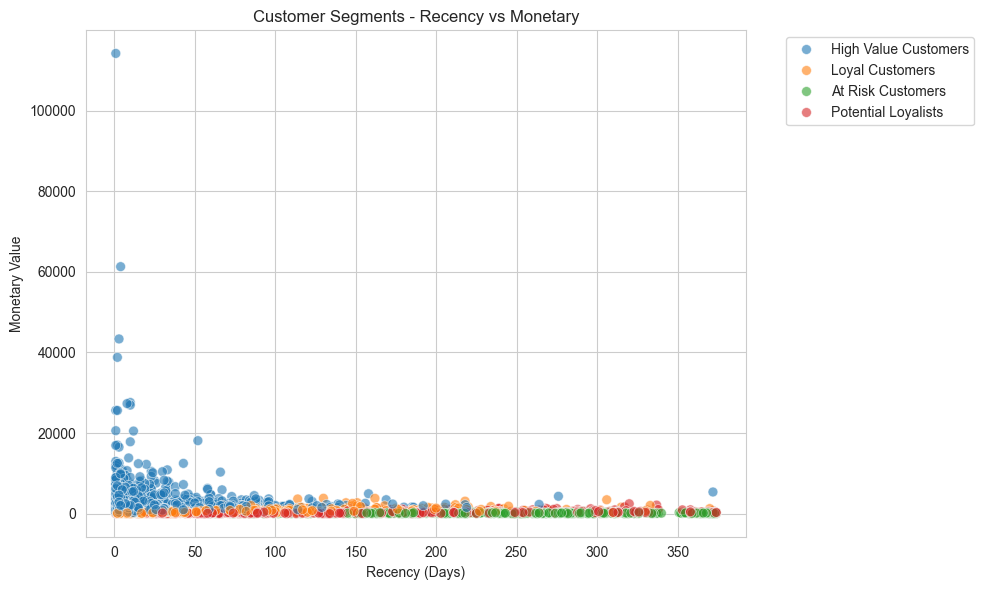

C:\Users\aadit\AppData\Local\Temp\ipykernel_17012\3768553368.py:85: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rfm_pivot = rfm.pivot_table(index='R_Score', columns='F_Score', values='Monetary', aggfunc='mean')


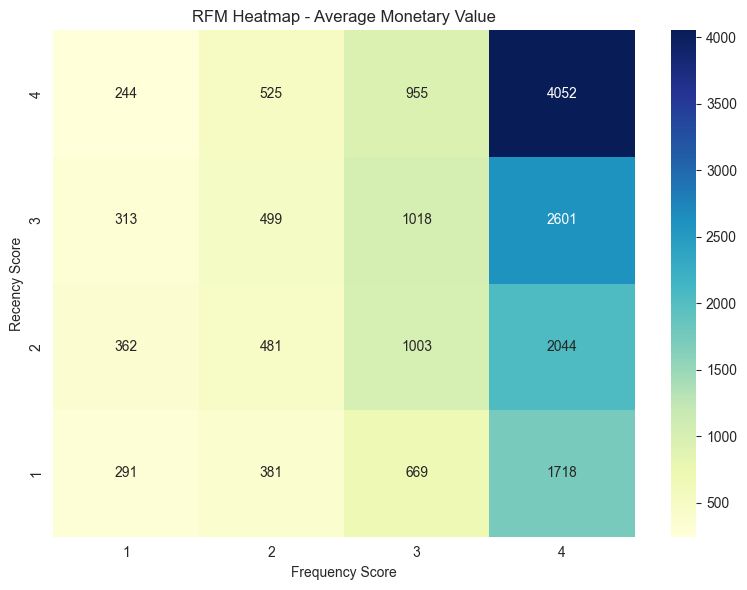

RFM ANALYSIS - KEY INSIGHTS
Total Customers Analyzed: 4238
Total Revenue: $5,326,594.35

Customer Distribution:
High Value Customers: 1639 (38.7%) - Revenue: $4,262,333.11
Potential Loyalists: 994 (23.5%) - Revenue: $363,600.03
Loyal Customers: 828 (19.5%) - Revenue: $554,359.96
At Risk Customers: 777 (18.3%) - Revenue: $146,301.25

BUSINESS RECOMMENDATIONS
1. Reward High Value Customers with exclusive loyalty programs
2. Re-engage At Risk and Lost Customers with targeted offers
3. Convert Potential Loyalists through personalized campaigns
4. Focus retention strategies on Loyal Customers
5. Implement win-back campaigns for customers with high recency


In [27]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df = df[df['TotalPrice'] > 0]
df = df[df['Quantity'] > 0]
df = df.dropna(subset=['CustomerID'])

df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=4, labels=[1, 2, 3, 4])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

def segment_customer(row):
    if row['RFM_Total'] >= 9:
        return 'High Value Customers'
    elif row['RFM_Total'] >= 7:
        return 'Loyal Customers'
    elif row['RFM_Total'] >= 5:
        return 'Potential Loyalists'
    elif row['RFM_Total'] >= 3:
        return 'At Risk Customers'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

segment_analysis = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum', 'count']
}).round(2)

print(segment_analysis)

plt.figure(figsize=(10, 6))
segment_counts = rfm['Segment'].value_counts()
plt.bar(segment_counts.index, segment_counts.values, color='steelblue')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Count by Segment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
segment_revenue = rfm.groupby('Segment')['Monetary'].sum()
plt.pie(segment_revenue, labels=segment_revenue.index, autopct='%1.1f%%', startangle=90)
plt.title('Revenue Contribution by Segment')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
segment_revenue_bar = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
plt.bar(segment_revenue_bar.index, segment_revenue_bar.values, color='coral')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by Segment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Segment', s=50, alpha=0.6)
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.title('Customer Segments - Recency vs Monetary')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

rfm_pivot = rfm.pivot_table(index='R_Score', columns='F_Score', values='Monetary', aggfunc='mean')
plt.figure(figsize=(8, 6))
sns.heatmap(rfm_pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('RFM Heatmap - Average Monetary Value')
plt.xlabel('Frequency Score')
plt.ylabel('Recency Score')
plt.tight_layout()
plt.show()

print("RFM ANALYSIS - KEY INSIGHTS")
print("="*50)
print(f"Total Customers Analyzed: {len(rfm)}")
print(f"Total Revenue: ${rfm['Monetary'].sum():,.2f}")
print(f"\nCustomer Distribution:")
for segment in rfm['Segment'].value_counts().index:
    count = rfm[rfm['Segment'] == segment].shape[0]
    revenue = rfm[rfm['Segment'] == segment]['Monetary'].sum()
    pct = (count / len(rfm)) * 100
    print(f"{segment}: {count} ({pct:.1f}%) - Revenue: ${revenue:,.2f}")
print("\nBUSINESS RECOMMENDATIONS")
print("="*50)
print("1. Reward High Value Customers with exclusive loyalty programs")
print("2. Re-engage At Risk and Lost Customers with targeted offers")
print("3. Convert Potential Loyalists through personalized campaigns")
print("4. Focus retention strategies on Loyal Customers")
print("5. Implement win-back campaigns for customers with high recency")

In [28]:
#customer segementation using rfm 

df = df.dropna(subset=['CustomerID'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm['R'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = rfm[['R','F','M']].astype(int).sum(axis=1)

def segment(row):
    if row >= 13:
        return 'Champions'
    elif row >= 10:
        return 'Loyal Customers'
    elif row >= 7:
        return 'Potential Loyalists'
    elif row >= 5:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

segment_summary = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'RFM_Score': 'count'
}).rename(columns={'RFM_Score': 'CustomerCount'}).sort_values(by='CustomerCount', ascending=False)

revenue_segment = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

In [29]:
df_rfm = df.merge(rfm[['Segment']], left_on='CustomerID', right_index=True)

segment_behavior = df_rfm.groupby('Segment').agg({
    'InvoiceNo': 'nunique',
    'CustomerID': 'nunique',
    'TotalPrice': 'sum',
    'Quantity': 'sum'
})

segment_behavior['Avg_Order_Value'] = segment_behavior['TotalPrice'] / segment_behavior['InvoiceNo']
segment_behavior['Purchase_Frequency'] = segment_behavior['InvoiceNo'] / segment_behavior['CustomerID']

top_products_segment = df_rfm.groupby(['Segment','Description'])['Quantity'].sum().reset_index()
top_products_segment = top_products_segment.sort_values(['Segment','Quantity'], ascending=[True, False])
top_products_segment = top_products_segment.groupby('Segment').head(5)

country_segment = df_rfm.groupby(['Segment','Country'])['TotalPrice'].sum().reset_index()
country_segment = country_segment.sort_values(['Segment','TotalPrice'], ascending=[True, False])

In [30]:
product_sales = df.groupby('Description').agg({
    'Quantity': 'sum',
    'TotalPrice': 'sum'
}).sort_values(by='TotalPrice', ascending=False)

top_products = product_sales.head(10)

low_products = product_sales.tail(10)

invoice_product = df.groupby(['InvoiceNo','Description'])['Quantity'].sum().unstack().fillna(0)
invoice_product = (invoice_product > 0).astype(int)

from itertools import combinations
from collections import Counter

pair_counts = Counter()

for row in invoice_product.iterrows():
    items = row[1][row[1] == 1].index.tolist()
    pair_counts.update(combinations(items, 2))

top_pairs = pd.DataFrame(pair_counts.items(), columns=['Product_Pair','Count']).sort_values(by='Count', ascending=False).head(10)


C:\Users\aadit\AppData\Local\Temp\ipykernel_17012\3527784994.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30)
C:\Users\aadit\AppData\Local\Temp\ipykernel_17012\3527784994.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30)


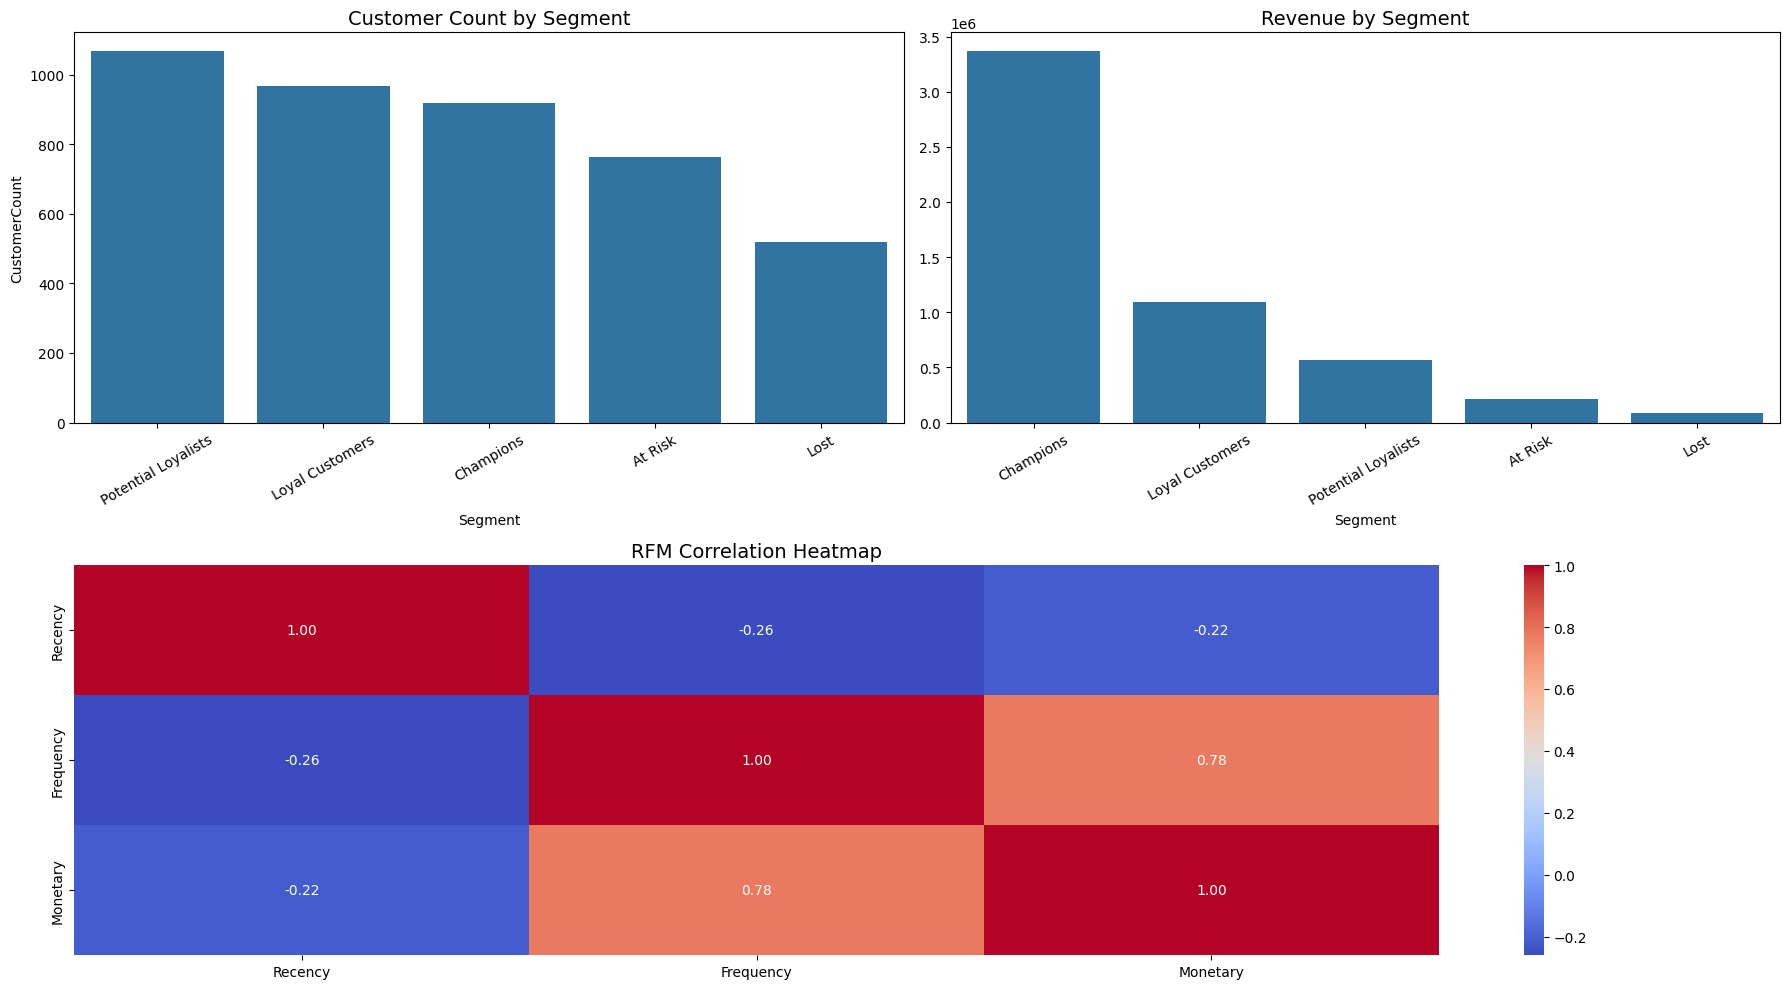

In [31]:


plt.figure(figsize=(18,10))
plt.style.use('default')

gs = plt.GridSpec(2, 2)

ax1 = plt.subplot(gs[0, 0])
sns.barplot(x=segment_summary.index, y=segment_summary['CustomerCount'], ax=ax1)
ax1.set_title('Customer Count by Segment', fontsize=14)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30)

ax2 = plt.subplot(gs[0, 1])
sns.barplot(x=revenue_segment.index, y=revenue_segment.values, ax=ax2)
ax2.set_title('Revenue by Segment', fontsize=14)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30)

ax3 = plt.subplot(gs[1, :])
sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax3)
ax3.set_title('RFM Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.show()

C:\Users\aadit\AppData\Local\Temp\ipykernel_17012\3228677532.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30)
C:\Users\aadit\AppData\Local\Temp\ipykernel_17012\3228677532.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30)
C:\Users\aadit\AppData\Local\Temp\ipykernel_17012\3228677532.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(ax3.get_xticklabels(), rotation=30)


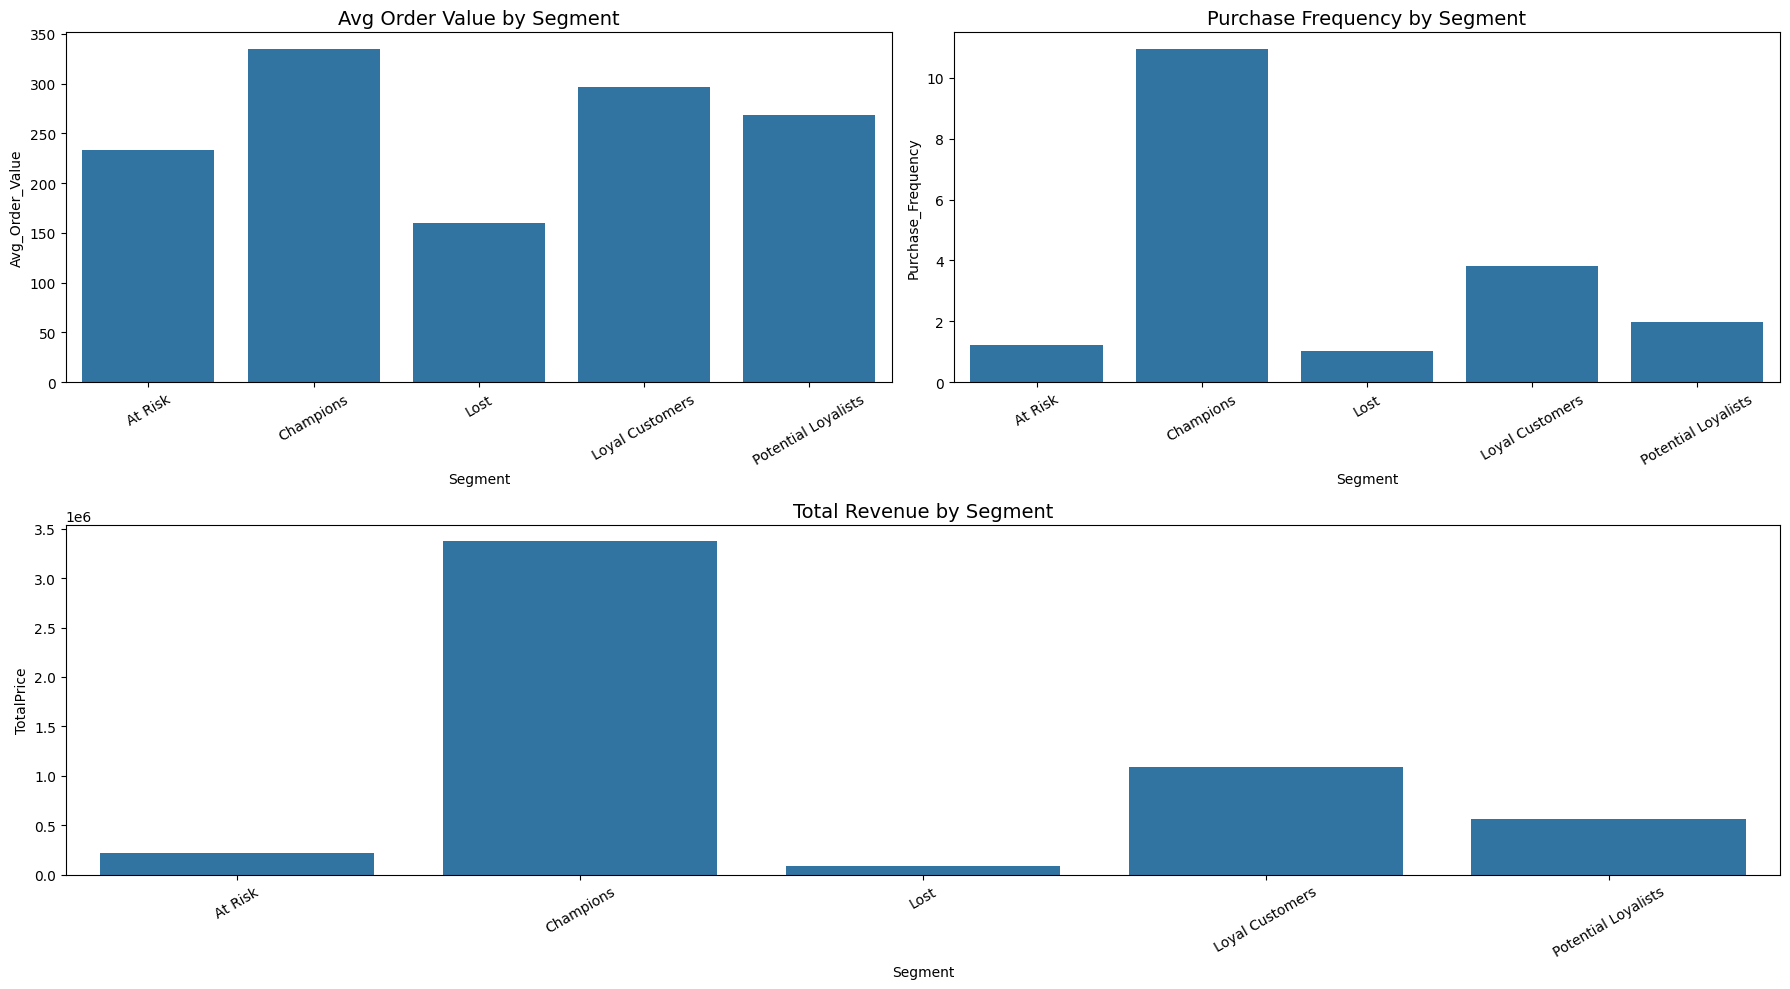

In [32]:
plt.figure(figsize=(18,10))

gs = plt.GridSpec(2, 2)

ax1 = plt.subplot(gs[0, 0])
sns.barplot(x=segment_behavior.index, y=segment_behavior['Avg_Order_Value'], ax=ax1)
ax1.set_title('Avg Order Value by Segment', fontsize=14)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30)

ax2 = plt.subplot(gs[0, 1])
sns.barplot(x=segment_behavior.index, y=segment_behavior['Purchase_Frequency'], ax=ax2)
ax2.set_title('Purchase Frequency by Segment', fontsize=14)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30)

ax3 = plt.subplot(gs[1, :])
sns.barplot(x=segment_behavior.index, y=segment_behavior['TotalPrice'], ax=ax3)
ax3.set_title('Total Revenue by Segment', fontsize=14)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()

C:\Users\aadit\AppData\Local\Temp\ipykernel_17012\3421764522.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=60)


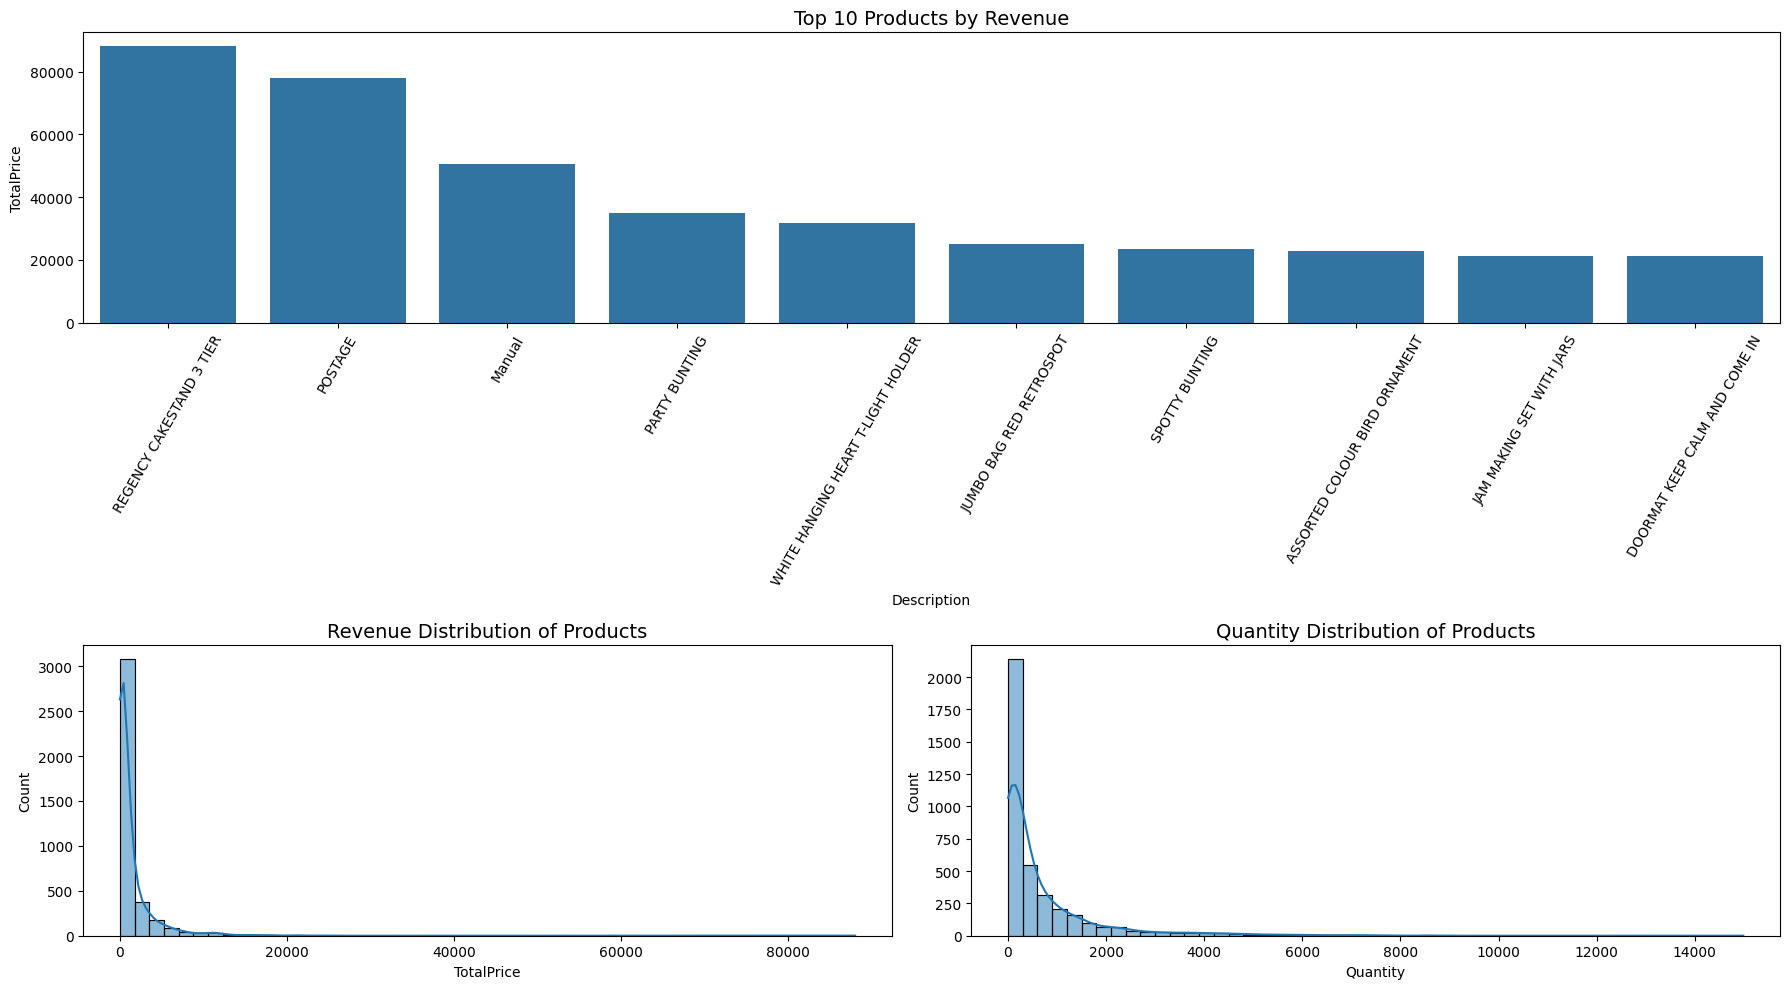

In [33]:
plt.figure(figsize=(18,10))

gs = plt.GridSpec(2, 2)

ax1 = plt.subplot(gs[0, :])
sns.barplot(x=top_products.index, y=top_products['TotalPrice'], ax=ax1)
ax1.set_title('Top 10 Products by Revenue', fontsize=14)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=60)

ax2 = plt.subplot(gs[1, 0])
sns.histplot(product_sales['TotalPrice'], bins=50, kde=True, ax=ax2)
ax2.set_title('Revenue Distribution of Products', fontsize=14)

ax3 = plt.subplot(gs[1, 1])
sns.histplot(product_sales['Quantity'], bins=50, kde=True, ax=ax3)
ax3.set_title('Quantity Distribution of Products', fontsize=14)

plt.tight_layout()
plt.show()

C:\Users\aadit\AppData\Local\Temp\ipykernel_17012\104440138.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)


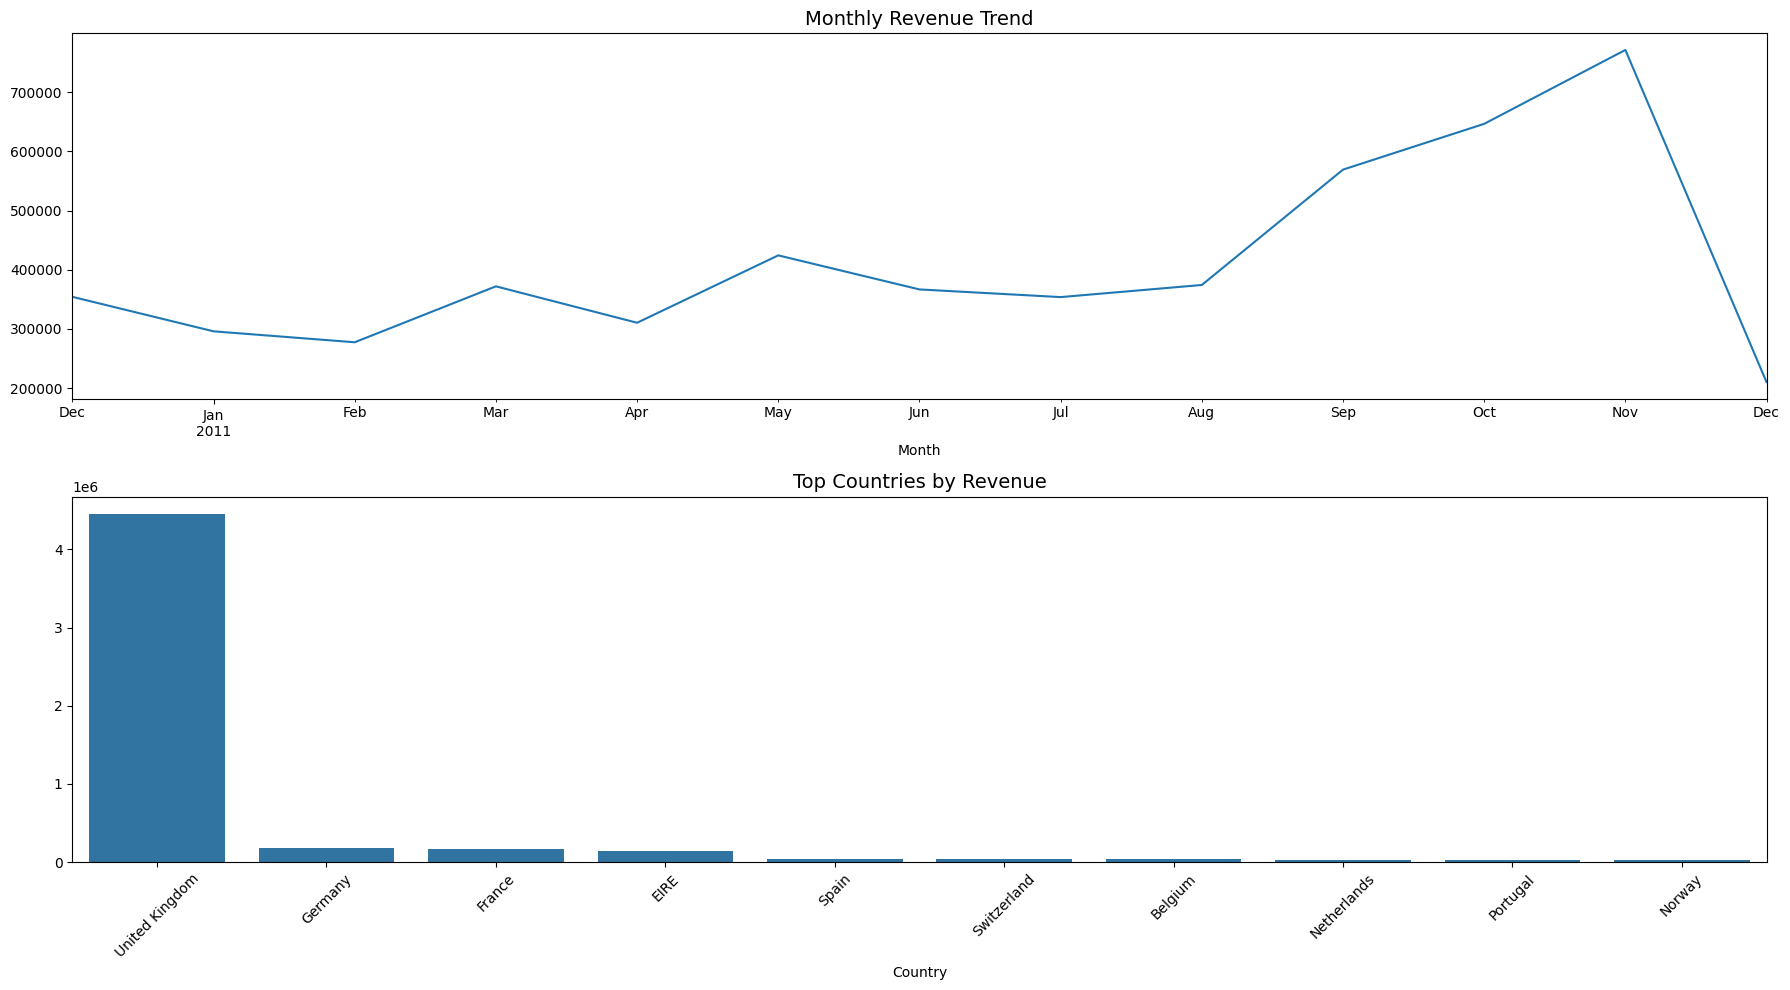

In [34]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['TotalPrice'].sum()

top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(18,10))

gs = plt.GridSpec(2, 1)

ax1 = plt.subplot(gs[0, 0])
monthly_revenue.plot(ax=ax1)
ax1.set_title('Monthly Revenue Trend', fontsize=14)

ax2 = plt.subplot(gs[1, 0])
sns.barplot(x=top_countries.index, y=top_countries.values, ax=ax2)
ax2.set_title('Top Countries by Revenue', fontsize=14)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

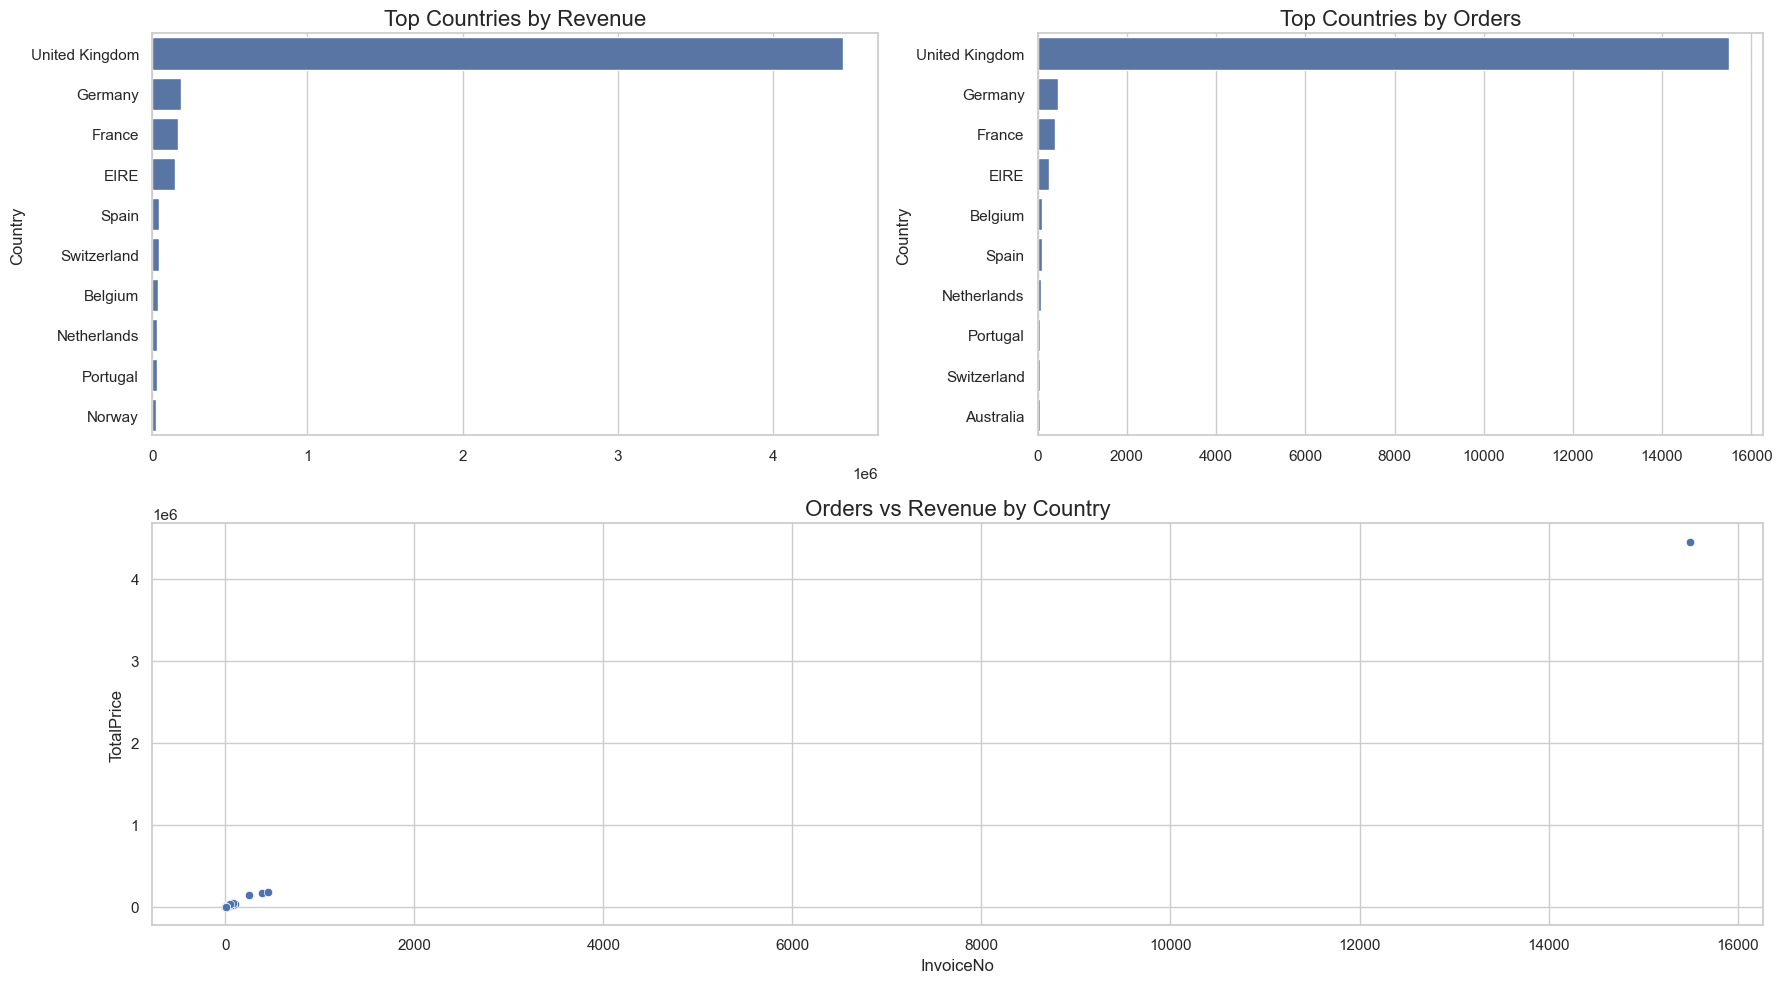

In [35]:


sns.set_theme(style="whitegrid")

country_rev = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
country_orders = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(18,10))
gs = plt.GridSpec(2,2)

ax1 = plt.subplot(gs[0,0])
sns.barplot(x=country_rev.values, y=country_rev.index, ax=ax1)
ax1.set_title('Top Countries by Revenue', fontsize=16)

ax2 = plt.subplot(gs[0,1])
sns.barplot(x=country_orders.values, y=country_orders.index, ax=ax2)
ax2.set_title('Top Countries by Orders', fontsize=16)

ax3 = plt.subplot(gs[1,:])
sns.scatterplot(
    x=df.groupby('Country')['InvoiceNo'].nunique(),
    y=df.groupby('Country')['TotalPrice'].sum()
)
ax3.set_title('Orders vs Revenue by Country', fontsize=16)

plt.tight_layout()
plt.show()

C:\Users\aadit\AppData\Local\Temp\ipykernel_17012\3321975481.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30)


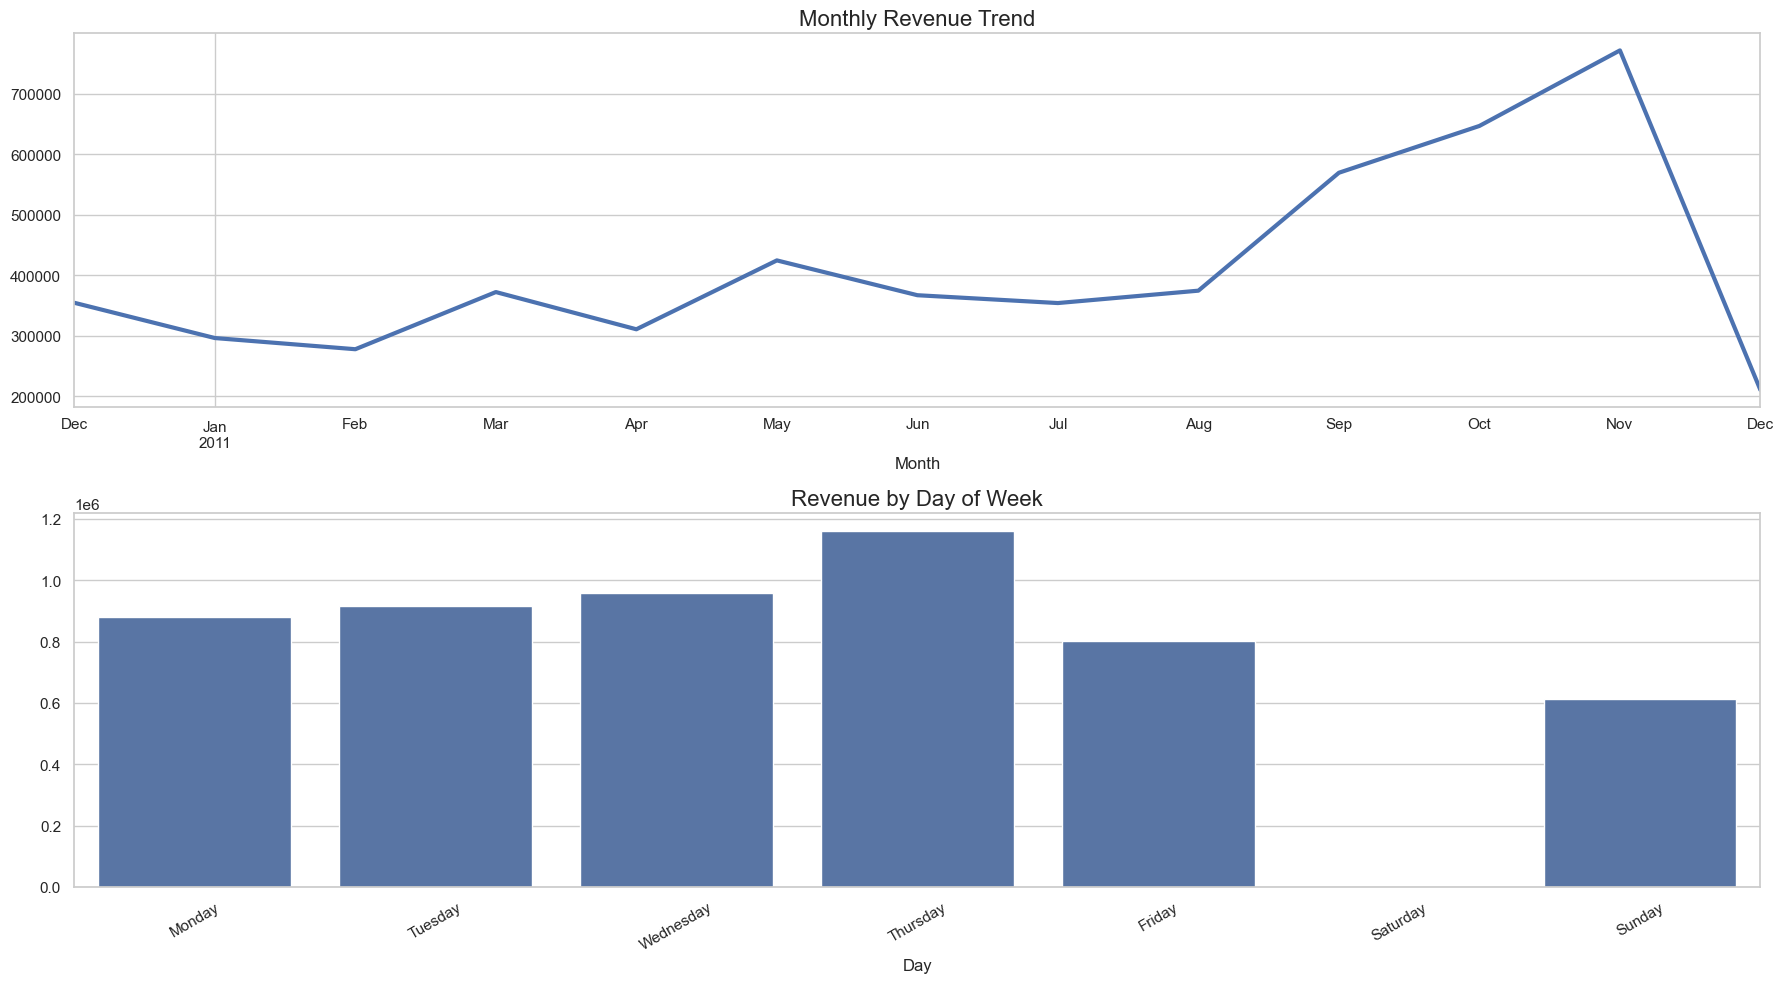

In [36]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['Day'] = df['InvoiceDate'].dt.day_name()

monthly_rev = df.groupby('Month')['TotalPrice'].sum()
daily_rev = df.groupby('Day')['TotalPrice'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

plt.figure(figsize=(18,10))
gs = plt.GridSpec(2,1)

ax1 = plt.subplot(gs[0,0])
monthly_rev.plot(ax=ax1, linewidth=3)
ax1.set_title('Monthly Revenue Trend', fontsize=16)

ax2 = plt.subplot(gs[1,0])
sns.barplot(x=daily_rev.index, y=daily_rev.values, ax=ax2)
ax2.set_title('Revenue by Day of Week', fontsize=16)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()

C:\Users\aadit\AppData\Local\Temp\ipykernel_17012\566716170.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30)


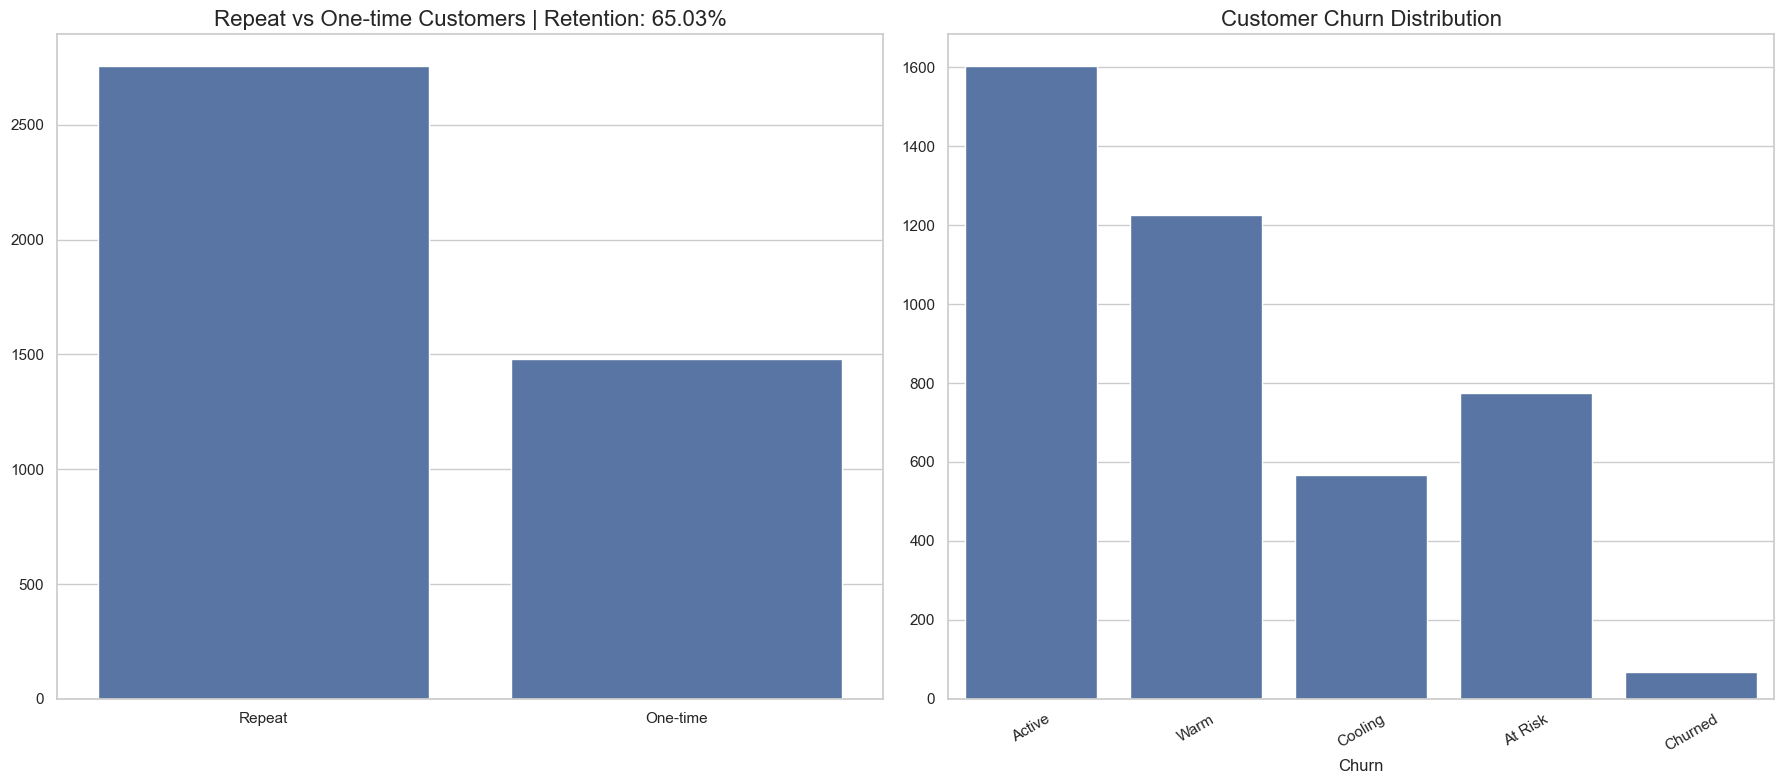

In [37]:
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()

repeat = (customer_orders > 1).sum()
one_time = (customer_orders == 1).sum()

retention_rate = repeat / len(customer_orders)

rfm['Churn'] = pd.cut(rfm['Recency'], bins=[-1,30,90,180,365,10000],labels=['Active','Warm','Cooling','At Risk','Churned'])

churn_dist = rfm['Churn'].value_counts()

plt.figure(figsize=(18,8))
gs = plt.GridSpec(1,2)

ax1 = plt.subplot(gs[0,0])
sns.barplot(x=['Repeat','One-time'], y=[repeat, one_time], ax=ax1)
ax1.set_title(f'Repeat vs One-time Customers | Retention: {retention_rate:.2%}', fontsize=16)

ax2 = plt.subplot(gs[0,1])
sns.barplot(x=churn_dist.index, y=churn_dist.values, ax=ax2)
ax2.set_title('Customer Churn Distribution', fontsize=16)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()

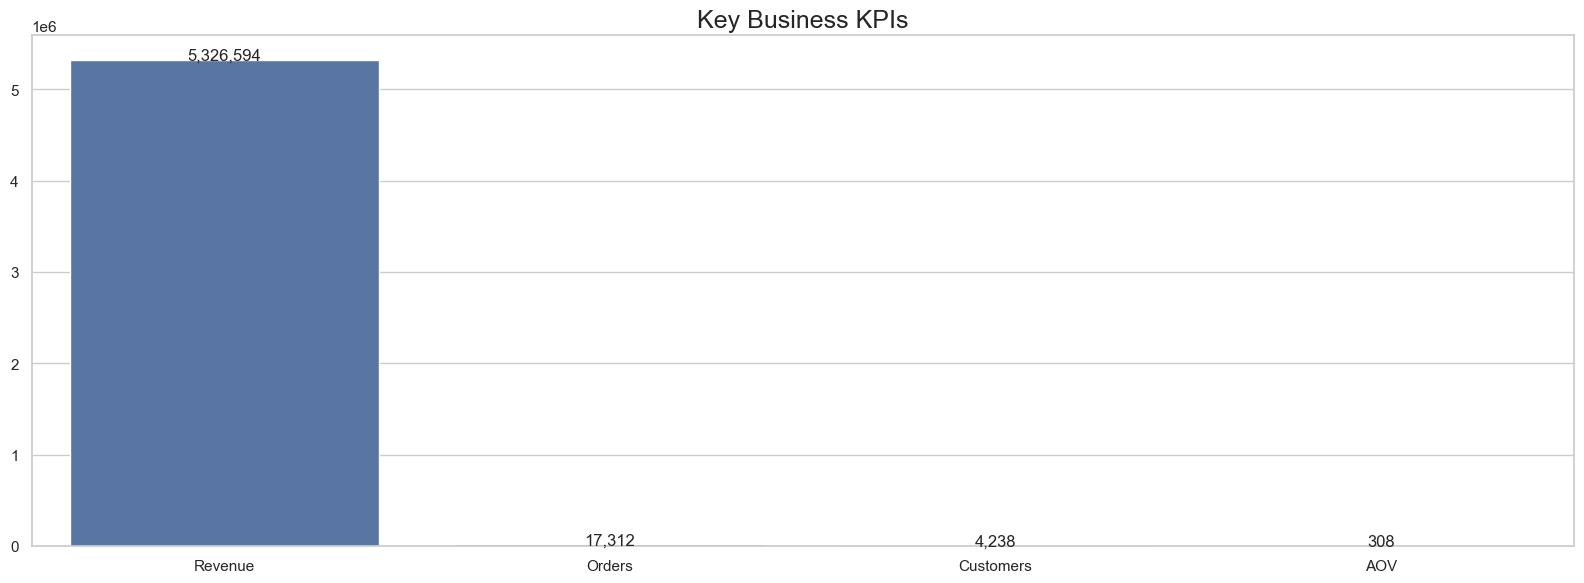

In [38]:
total_revenue = df['TotalPrice'].sum()
total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
aov = total_revenue / total_orders
plt.figure(figsize=(16,6))
metrics = ['Revenue','Orders','Customers','AOV']
values = [total_revenue, total_orders, total_customers, aov]
sns.barplot(x=metrics, y=values)
plt.title('Key Business KPIs', fontsize=18)
for i, v in enumerate(values):
    plt.text(i, v, f'{v:,.0f}', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

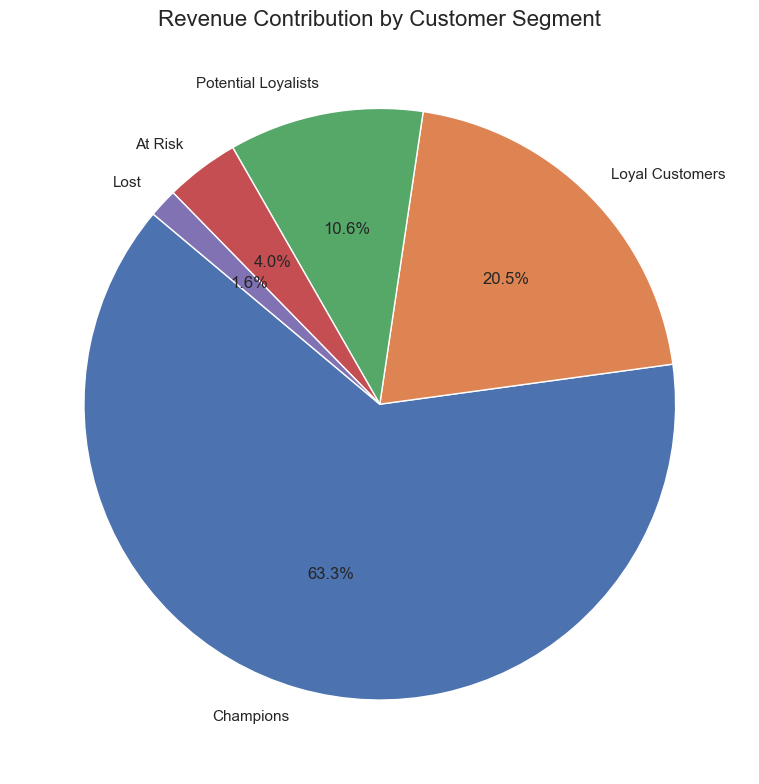

In [39]:
segment_rev = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,8))
plt.pie(segment_rev.values, labels=segment_rev.index, autopct='%1.1f%%', startangle=140)
plt.title('Revenue Contribution by Customer Segment', fontsize=16)
plt.tight_layout()
plt.show()

C:\Users\aadit\AppData\Local\Temp\ipykernel_17012\1420798991.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=60)


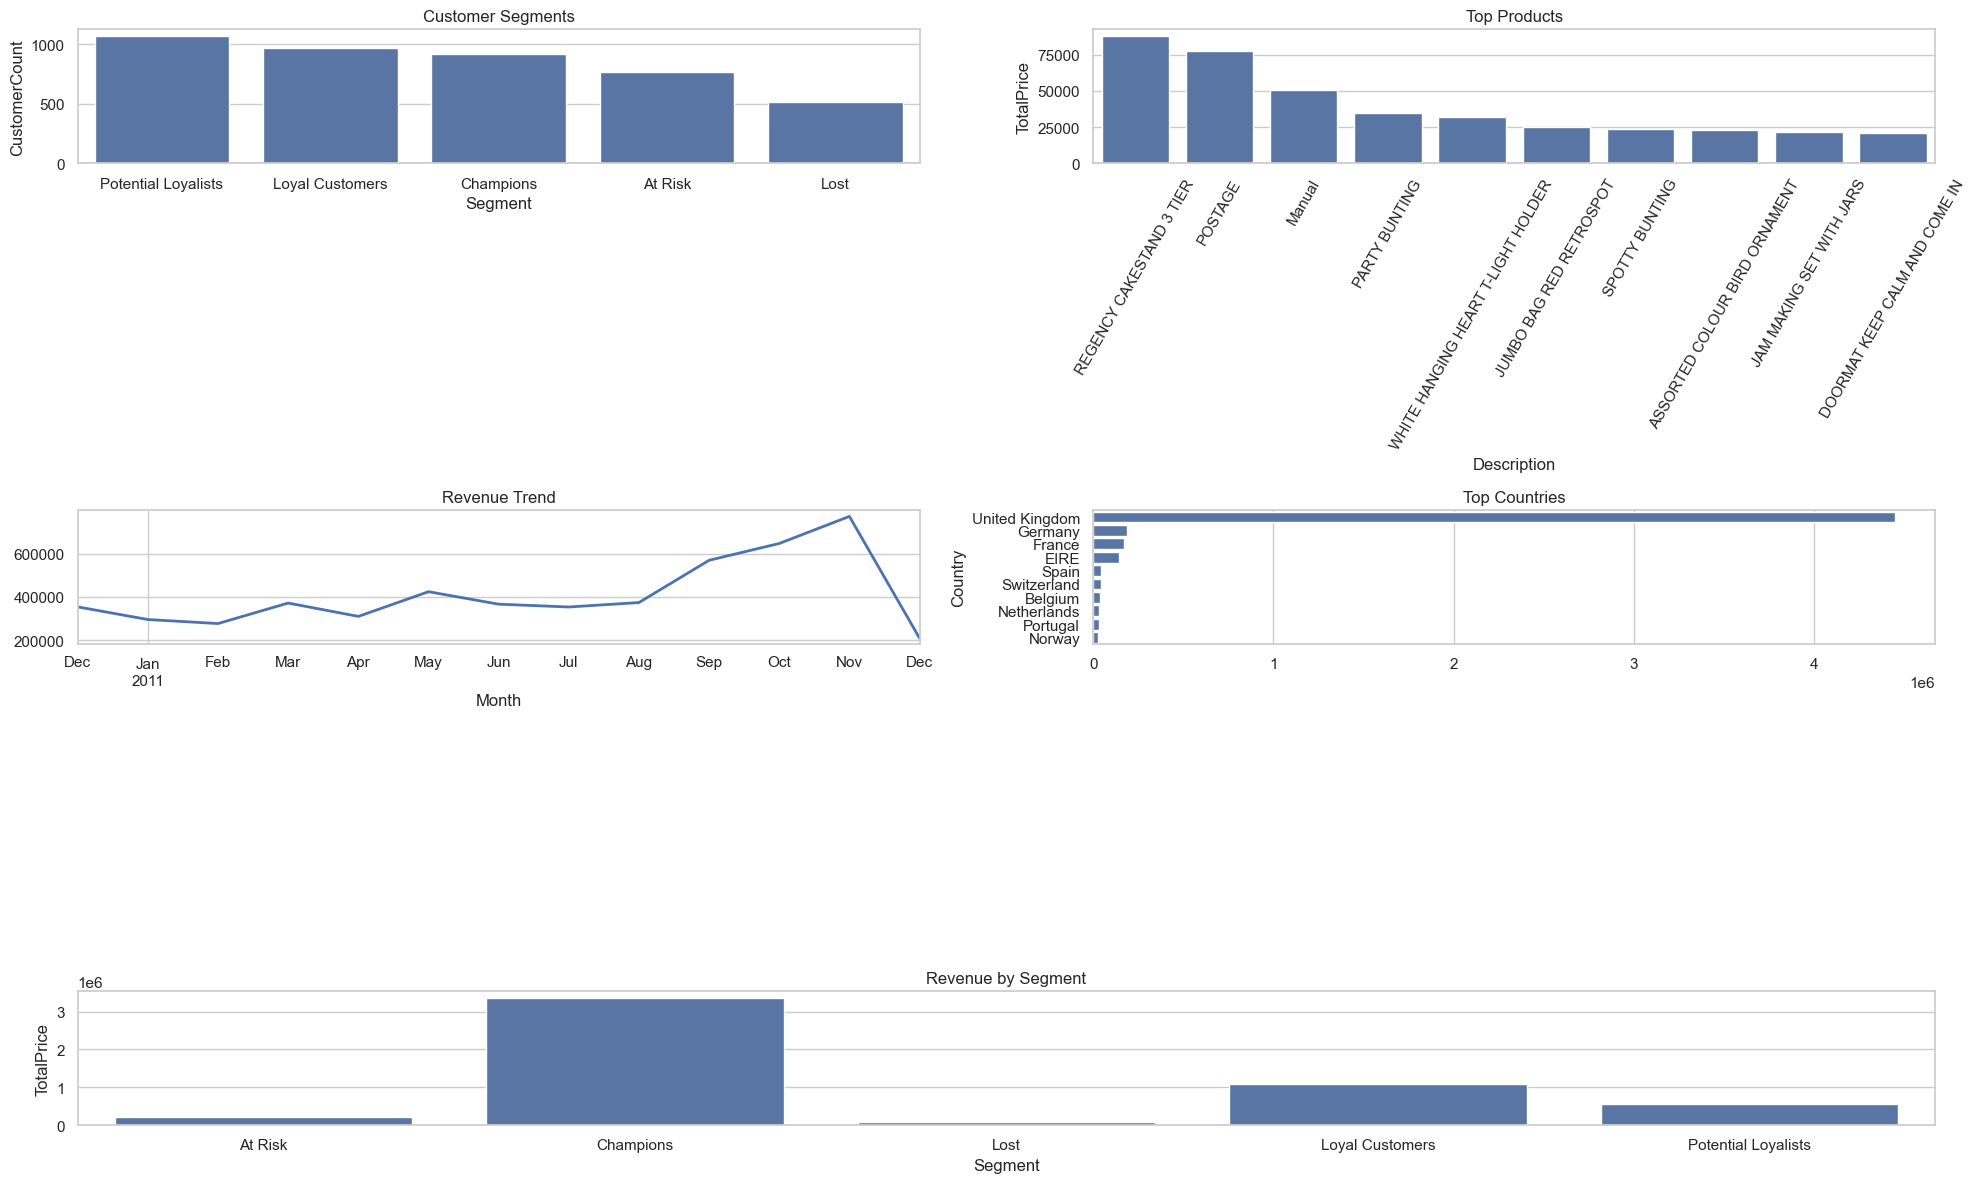

In [40]:
plt.figure(figsize=(20,12))
gs = plt.GridSpec(3,2)
ax1 = plt.subplot(gs[0,0])
sns.barplot(x=segment_summary.index, y=segment_summary['CustomerCount'], ax=ax1)
ax1.set_title('Customer Segments')
ax2 = plt.subplot(gs[0,1])
sns.barplot(x=top_products.index, y=top_products['TotalPrice'], ax=ax2)
ax2.set_title('Top Products')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=60)
ax3 = plt.subplot(gs[1,0])
monthly_rev.plot(ax=ax3, linewidth=2)
ax3.set_title('Revenue Trend')
ax4 = plt.subplot(gs[1,1])
sns.barplot(x=country_rev.values, y=country_rev.index, ax=ax4)
ax4.set_title('Top Countries')
ax5 = plt.subplot(gs[2, :])
sns.barplot(x=segment_behavior.index, y=segment_behavior['TotalPrice'], ax=ax5)
ax5.set_title('Revenue by Segment')
plt.tight_layout()
plt.show()